# Clone Repository and set up the Environment

In [2]:
!pwd

/content


In [3]:
!git clone https://github.com/VictoryChianumba/robust-eeg-models

Cloning into 'robust-eeg-models'...
remote: Enumerating objects: 3342, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 3342 (delta 89), reused 85 (delta 60), pack-reused 3214 (from 3)
Receiving objects: 100% (3342/3342), 835.36 MiB | 16.67 MiB/s, done.
Resolving deltas: 100% (1286/1286), done.
Updating files: 100% (2250/2250), done.
Filtering content: 100% (2/2), 663.03 MiB | 31.13 MiB/s, done.


In [1]:
%cd robust-eeg-models

/content/robust-eeg-models


In [3]:
!git config --global user.email "chianumbav@gmial.com"
!git config --global user.name "Victory Chianumba"

In [ ]:
# 1️⃣ Upgrade the package manager
!pip install --upgrade --quiet pip

!pip install torch torchvision torchaudio
!pip install mne moabb
!pip install torch-lr-finder
!pip install optuna
!pip install torchattacks
!pip install advertorch
!pip install foolbox
!pip install captum

# Clean uninstall of briandecode
!pip uninstall -y braindecode

# Install latest braindecode and autoattack code from GitHub (which includes braindecode CTNet)
!pip install git+https://github.com/braindecode/braindecode.git@master --no-cache-dir
!pip install git+https://github.com/fra31/auto-attack

In [4]:
import braindecode
print("Braindecode version:", braindecode.__version__)

from braindecode.models import CTNet
print("CTNet is available ✅")


Braindecode version: 1.2.0
CTNet is available ✅


In [5]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"   # or ":16:8" if memory is tight
os.environ["PYTHONHASHSEED"] = "0"                  # optional, extra stability


In [6]:
import torch, torchattacks, foolbox, optuna, autoattack, captum
# import advertorch
import importlib, sys, pickle, json, random, time, datetime, numbers, hashlib, subprocess

import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [7]:
from datetime import datetime
from collections import defaultdict

from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR, CosineAnnealingWarmRestarts

from braindecode import EEGClassifier
from braindecode.models import EEGNetv4, Deep4Net, CTNet
from braindecode.datasets import MOABBDataset
from braindecode.augmentation import FrequencyShift, GaussianNoise, AugmentedDataLoader, Compose, SmoothTimeMask, Mixup
from braindecode.training import mixup_criterion

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from skorch.helper import predefined_split
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from sklearn.metrics import jaccard_score
from sklearn.metrics.pairwise import cosine_similarity

# Use to visualise the embeddings, COULD be used to visualise the explanations
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from scipy.stats import spearmanr

#EEGMamba-MOE approximation
from models.eeg_mamba_fft import create_eegmamba, EEGMamba

# Loading data for training

In [8]:
#import numpy as np
from braindecode.datasets import MOABBDataset
from braindecode.preprocessing import Preprocessor, exponential_moving_standardize, preprocess
from braindecode.preprocessing import create_windows_from_events
from sklearn.model_selection import train_test_split
from skorch.helper import SliceDataset
from torch.utils.data import Subset

device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = MOABBDataset(
    dataset_name='BNCI2014001', subject_ids=[1]
)

#----------------------------------------------------------------------
# After loading we preprocess

low_cut_hz = 4.0  # low cut frequency for filtering
high_cut_hz = 38.0  # high cut frequency for filtering
# Parameters for exponential moving standardization
factor_new = 1e-3
init_block_size = 1000



# 1) Split preprocessors
pre_noems = [
    Preprocessor("pick_types", eeg=True, meg=False, stim=False),
    Preprocessor(lambda data, factor: np.multiply(data, factor), factor=1e6),  # V→µV
    Preprocessor("filter", l_freq=low_cut_hz, h_freq=high_cut_hz),
]
pre_ems = [
    Preprocessor(exponential_moving_standardize, factor_new=factor_new, init_block_size=init_block_size),
]

# ---- PASS 1: pre-EMS (to get physical stats) ----
preprocess(dataset, pre_noems, n_jobs=-1)

#-----------------------------------------------------------------------

trial_start_offset_seconds = -0.5
# Extract sampling frequency, check that they are same in all datasets
sfreq = dataset.datasets[0].raw.info["sfreq"]
assert all([ds.raw.info["sfreq"] == sfreq for ds in dataset.datasets])
# Calculate the window start offset in samples.
trial_start_offset_samples = int(trial_start_offset_seconds * sfreq)

# Create windows using braindecode function for this. It needs parameters to
# define how windows should be used.
windows_pre = create_windows_from_events(
    dataset,
    trial_start_offset_samples = int(-0.5 * sfreq) , # -0.5s before cue
    trial_stop_offset_samples = 0,   # 4.0s after cue (t=2s to t=6s)
    preload=True,
    # verbose=0
)

# ----------------------------------------------------------------------
# Split into train and test
splitted = windows_pre.split("session")
train_set_pre = splitted["0train"]  # Session train
test_set_pre = splitted["1test"]  # Session evaluation


X_train_pre = np.stack([train_set_pre[i][0] for i in range(len(train_set_pre))])  # (N,C,T)
train_mean_pre = X_train_pre.mean(axis=(0, 2), keepdims=True)          # (1,C,1)
train_std_pre  = X_train_pre.std(axis=(0, 2), keepdims=True) + 1e-6    # (1,C,1)
train_min_pre  = X_train_pre.min(axis=(0, 2), keepdims=True)
train_max_pre  = X_train_pre.max(axis=(0, 2), keepdims=True)

# Save prenorm stats + channel names for later mapping/clamping
ch_names_pre = windows_pre.datasets[0].raw.info["ch_names"]
os.makedirs("results", exist_ok=True)
np.savez(f"results/S{1}_prenorm_stats.npz",  # <-- replace 1 with your subject id var
         mean=train_mean_pre, std=train_std_pre,
         vmin=train_min_pre, vmax=train_max_pre,
         ch_names=np.array(ch_names_pre))

# ---- PASS 2: append EMS and rebuild windows for training/eval ----
preprocess(dataset, pre_ems, n_jobs=-1)

windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=int(-0.5 * sfreq),
    trial_stop_offset_samples=0,
    preload=True,
)

# now continue exactly as you already do, but on windows_dataset:
splitted = windows_dataset.split("session")
train_set = splitted["0train"]
test_set  = splitted["1test"]


# Build simple tensors to compute stats on train windows only
X_train = SliceDataset(train_set, idx=0)

y_train = np.array([y for y in SliceDataset(train_set, idx=1)])

X_test = np.stack([test_set[i][0] for i in range(len(test_set))])  # (N,C,T)
y_test = np.array(test_set.get_metadata().target)                   # (N,)

train_indices, val_indices = train_test_split(
      X_train.indices_, test_size=0.2, shuffle=False
  )
train_subset = Subset(train_set, train_indices)
val_subset = Subset(train_set, val_indices)

X_train = np.stack([train_set[i][0] for i in range(len(train_set))])  # (N,C,T

# 3) materialize test tensors (NOT SliceDataset)
X = torch.tensor(X_test, dtype=torch.float32, device=device)
y = torch.tensor(y_test, dtype=torch.long, device=device)

x, y , meta = train_set[0]
print(type(x), x.shape, x.mean(), x.std())




# # Save these via _save_run(... train_mean=train_mean, train_std=train_std, train_min=train_min, train_max=train_max)


/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:56: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 71.4GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|█████████████████████████████████████| 43.8M/43.8M [

Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']

Check if this loads as train_set = x, y or x, y , meta

---
Useful for later

In [9]:
sample = train_set[0]
print(type(sample))
print(len(sample))   # see what fields exist ()
channel_names = dataset.datasets[0].raw.info['ch_names']
print(channel_names)

<class 'tuple'>
3
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']


## Set loading functions

In [10]:
def load_subject_data_cached(dataset, subject_id):
    cache_file = f'cache/{dataset}_S{subject_id}_l{low_cut_hz}_h{high_cut_hz}_ems{init_block_size}_{factor_new}.pkl'

    if os.path.exists(cache_file):
        # Load from cache - instant!
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    # Process and cache
    train_set, test_set, train_subset, val_subset , adv = load_subject_data(dataset,subject_id)

    os.makedirs('cache', exist_ok=True)
    with open(cache_file, 'wb') as f:
        pickle.dump((train_set, test_set, train_subset, val_subset, adv), f)


    return train_set, test_set, train_subset, val_subset, adv

def load_subject_data(dataset, subject_id):

    import numpy as np
    from braindecode.datasets import MOABBDataset
    from braindecode.preprocessing import Preprocessor, exponential_moving_standardize, preprocess
    from braindecode.preprocessing import create_windows_from_events
    from sklearn.model_selection import train_test_split
    from skorch.helper import SliceDataset
    from torch.utils.data import Subset

    dataset = MOABBDataset(
        dataset_name=dataset, subject_ids=[subject_id]
    )

    #----------------------------------------------------------------------
    # After loading we preprocess

    low_cut_hz = 4.0  # low cut frequency for filtering
    high_cut_hz = 38.0  # high cut frequency for filtering
    # Parameters for exponential moving standardization
    factor_new = 1e-3
    init_block_size = 750


    # 1) Split preprocessors
    pre_noems = [
        Preprocessor("pick_types", eeg=True, meg=False, stim=False),
        Preprocessor(lambda data, factor: np.multiply(data, factor), factor=1e6),  # V→µV
        Preprocessor("filter", l_freq=low_cut_hz, h_freq=high_cut_hz),
    ]
    pre_ems = [
        Preprocessor(exponential_moving_standardize, factor_new=factor_new, init_block_size=init_block_size),
    ]

    # ---- PASS 1: pre-EMS (to get physical stats) ----
    preprocess(dataset, pre_noems, n_jobs=-1)

    #-----------------------------------------------------------------------

    trial_start_offset_seconds = -0.5
    # Extract sampling frequency, check that they are same in all datasets
    sfreq = dataset.datasets[0].raw.info["sfreq"]
    assert all([ds.raw.info["sfreq"] == sfreq for ds in dataset.datasets])
    # Calculate the window start offset in samples.
    trial_start_offset_samples = int(trial_start_offset_seconds * sfreq)

    # Create windows using braindecode function for this. It needs parameters to
    # define how windows should be used.
    windows_pre = create_windows_from_events(
        dataset,
        trial_start_offset_samples = int(-0.5 * sfreq) , # -0.5s before cue
        trial_stop_offset_samples = 0,   # 4.0s after cue (t=2s to t=6s)
        preload=True,
        # verbose=0
    )

    # ----------------------------------------------------------------------
    # Split into train and test
    splitted = windows_pre.split("session")
    train_set_pre = splitted["0train"]  # Session train
    test_set_pre = splitted["1test"]  # Session evaluation

    #Calculate teh train mean, std, min and max
    X_train_pre = np.stack([train_set_pre[i][0] for i in range(len(train_set_pre))])  # (N,C,T)
    train_mean_pre = X_train_pre.mean(axis=(0, 2), keepdims=True)          # (1,C,1)
    train_std_pre  = X_train_pre.std(axis=(0, 2), keepdims=True) + 1e-6    # (1,C,1)
    train_min_pre  = X_train_pre.min(axis=(0, 2), keepdims=True)
    train_max_pre  = X_train_pre.max(axis=(0, 2), keepdims=True)

    # Save prenorm stats + channel names for later mapping/clamping
    ch_names_pre = train_set_pre.datasets[0].raw.info['ch_names']
    os.makedirs("results", exist_ok=True)
    np.savez(f"results/S{subject_id}_prenorm_stats.npz",  # <-- replace 1 with your subject id var
            mean=train_mean_pre, std=train_std_pre,
            vmin=train_min_pre, vmax=train_max_pre,
            ch_names=np.array(ch_names_pre))

    # ---- PASS 2: append EMS and rebuild windows for training/eval ----
    preprocess(dataset, pre_ems, n_jobs=-1)

    windows_dataset = create_windows_from_events(
        dataset,
        trial_start_offset_samples=int(-0.5 * sfreq),
        trial_stop_offset_samples=0,
        preload=True,
    )

    # now continue exactly as you already do, but on windows_dataset:
    splitted = windows_dataset.split("session")
    train_set = splitted["0train"]
    test_set  = splitted["1test"]


    # Build simple tensors to compute stats on train windows only
    X_train = SliceDataset(train_set, idx=0)

    y_train = np.array([y for y in SliceDataset(train_set, idx=1)])

    X_test = np.stack([test_set[i][0] for i in range(len(test_set))])  # (N,C,T)
    y_test = np.array(test_set.get_metadata().target)                   # (N,)

    train_indices, val_indices = train_test_split(
          X_train.indices_, test_size=0.2, shuffle=False
      )
    train_subset = Subset(train_set, train_indices)
    val_subset = Subset(train_set, val_indices)
    X_train = np.stack([train_set[i][0] for i in range(len(train_set))])  # (N,C,T

    adv = (train_mean_pre, train_std_pre, train_min_pre, train_max_pre)
    return train_set, test_set, train_subset, val_subset, adv


## Data loading sanity check

In [ ]:
# Run once or sanity check
subject_id = 1
train_set, test_set, train_subset, val_subset, adv = load_subject_data_cached("BNCI2014001", subject_id)
train_mean_pre, train_std_pre, train_min_pre, train_max_pre = adv


print(f"Window shape: {windows_dataset[0][0].shape}")
train_subset[0][0].shape[0]
channel_names = test_set.datasets[0].raw.info['ch_names']
print(channel_names)
print(train_mean_pre)
print(train_std_pre)
print(train_min_pre)
print(train_max_pre)

## Load and inspect model

In [ ]:
from braindecode.util import set_random_seeds

cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 20200220
set_random_seeds(seed=seed, cuda=cuda)

# Extract number of chans and time steps from dataset
n_channels = train_subset[0][0].shape[0]
n_times = train_subset[0][0].shape[1]
n_classes = len(np.unique([train_subset[i][1] for i in range(len(train_subset))]))
classes = list(range(n_classes))

model = CTNet(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
    # n_layers = 2,
    # n_experts = 8

)

# model.enable_moe(True)

# Send model to GPU
if cuda:
    model.cuda()

/usr/local/lib/python3.12/dist-packages/braindecode/util.py:52: UserWarning: torch.backends.cudnn.benchmark was set to True which may results in lack of reproducibility. In some cases to ensure reproducibility you may need to set torch.backends.cudnn.benchmark to False.
  warn(


# Training

## Set model hyper params

In [ ]:

eegnet_params = {'lr': 1e-3, 'batch_size': 64, 'weight_decay': 1e-4, 'optimizer': torch.optim.Adam}

deepconvnet_params = {'lr': 1e-3, 'batch_size': 64, 'weight_decay': 1e-4, 'optimizer': torch.optim.Adam}

CTNet_params = {'lr': 1e-3, 'batch_size': 64, 'weight_decay': 1e-4, 'optimizer': torch.optim.AdamW}
alt_params = {'lr': 1e-3, 'batch_size': 128, 'weight_decay': 5e-3, 'optimizer': torch.optim.AdamW}

mamba_params = {'lr': 2e-4, 'batch_size': 128, 'weight_decay': 1e-6, 'optimizer': torch.optim.AdamW}
mamba_params1 = {'lr': 0.0016, 'batch_size': 128, 'weight_decay': 5e-4, 'optimizer': torch.optim.AdamW}

n_epochs = 500

## Single run mode

Single training run for model debugging, sanity checks and testing non braindecode architectures (EEGMammba)



In [ ]:
def make_scheduler(optimizer, last_epoch=-1):
    return CosineAnnealingWarmRestarts(optimizer, T_0=300, T_mult=1, eta_min=1e-6, last_epoch=last_epoch)

device = "cuda" if torch.cuda.is_available() else "cpu"


# Load tehe training data
train_set, test_set, train_subset, val_subset= load_subject_data_cached("BNCI2014001", 1)

# Build transforms list
transforms = [
    FrequencyShift(probability=0.3, sfreq=250, max_delta_freq=0.3),
    GaussianNoise(probability=0.3, std=0.0),
    # Mixup(alpha=0.2,  beta_per_sample=True),               # ← returns (x, (y1, y2, lam))
]


# Extract model params from dataset, initialise model and set hyper-parameters
classes = torch.unique(torch.tensor([sample[1] for sample in train_subset])).tolist()
n_classes = len(classes)
n_channels = train_subset[0][0].shape[0]
n_times = train_subset[0][0].shape[1]

model = EEGMamba(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,


)

# Hyper params
params = mamba_params

# Toggle this to enable mamba (For EEGMamba only)
# model.enable_moe(True)

# Enable MoE head instead of standard classifier (For EEGMamba only)
# model.use_moe = False

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def make_scheduler(optimizer, last_epoch=-1):
    warmup = LinearLR(optimizer, start_factor=0.1, total_iters=10, last_epoch=last_epoch)
    cosine = CosineAnnealingLR(optimizer, T_max=n_epochs-10, last_epoch=last_epoch)
    return CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=1)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=1)

# Create new classifier with best parameters
clf = EEGClassifier(
    model,
    # iterator_train=AugmentedDataLoader,
    # iterator_train__transforms=transforms,
    # iterator_train__shuffle=True,

    # dataset = aug_train,
    criterion=torch.nn.CrossEntropyLoss,
    # criterion__base_criterion=torch.nn.CrossEntropyLoss(reduction='none'),

    train_split=predefined_split(val_subset),  # Use all training data

    optimizer=params['optimizer'],

    # Looking at subjects
    # optimizer = torch.optim.SGD,
    # optimizer__momentum=0.9,

    optimizer__lr=params['lr'],
    optimizer__weight_decay=params['weight_decay'],
    batch_size=params['batch_size'],
    callbacks=[
        "accuracy",
        # ("lr_scheduler", LRScheduler(make_scheduler))
        # ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
        # ("early_stopping", EarlyStopping(patience=200, monitor="valid_acc")),
    ],
    device=device,
    classes=classes,
    max_epochs=500,
)

# Train on full training set
clf.fit(train_subset, y=None)

# Evaluate the model after training
y_test = test_set.get_metadata().target
test_acc = clf.score(test_set, y=y_test)

print(f"Val acc with MoE: {(test_acc * 100):.2f}%")

import numbers


NameError: name 'torch' is not defined

# Record Baselines for chosen models

In [11]:
def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)  # PyTorch 1.11+
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_environment_fingerprint():
    pip_freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"]).decode()
    gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
    return {
        "python": sys.version,
        "pytorch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cudnn_version": torch.backends.cudnn.version(),
        "pip_freeze": pip_freeze.splitlines(),
    }

def tiny_json(base, model, id, seed, skorch_params, backend, notes):

  os.makedirs(base, exist_ok=True)
  tiny = {
      "model_name": model,
      "subject_id": id,
      "seed": seed,
      "bandpass": {"l_freq": 4.0, "h_freq": 38.0},
      "unit_scale_to_uV": 1e6,
      "ems": {"factor_new": 1e-3, "init_block_size": 750},
      "trial_start_offset_seconds": -0.5,
      "windowing": "create_windows_from_events(session split: 0train/1test)",
      "zscore_applied": False,
      "skorch_params": skorch_params,
      "backend":backend,
      "notes": notes
  }
  return tiny

def safe_model_config(model_config: dict) -> dict:
    """Convert model_config into a JSON-serializable dict."""
    safe_cfg = {}
    for k, v in model_config.items():
        if k == "model_class":
            # store full module path + class name
            safe_cfg[k] = f"{v.__module__}.{v.__name__}" if hasattr(v, "__module__") else str(v)
        elif k == "training":
            safe_training = {}
            for tk, tv in v.items():
                if tk == "optimizer":
                    # also store optimizer class name
                    safe_training[tk] = f"{tv.__module__}.{tv.__name__}" if hasattr(tv, "__module__") else str(tv)
                else:
                    # assume JSON-friendly scalar
                    safe_training[tk] = tv
            safe_cfg[k] = safe_training
        else:
            safe_cfg[k] = v if isinstance(v, (int, float, str, bool, type(None))) else str(v)
    return safe_cfg



In [ ]:
def train_single_run(model_name, subject_id, seed, dataset):

    # 0. RNG reproducibility ---------------------------------------------------

    set_all_seeds(seed)
    rng_state_np    = np.random.get_state()
    rng_state_torch = torch.get_rng_state()
    env_fp          = get_environment_fingerprint()

    print(f"\n=== Processing Subject {subject_id} for seed {seed} ===")

    # 1. data ------------------------------------------------------------------
    # Load data
    train_set, test_set, train_subset, val_subset, adv  = load_subject_data_cached(dataset, subject_id)

    # Build simple tensors to compute stats on train windows only
    X_train = np.stack([train_set[i][0] for i in range(len(train_set))])  # (N,C,T)
    train_mean = X_train.mean(axis=(0,2), keepdims=True)  # (1,C,1)
    train_std  = X_train.std(axis=(0,2), keepdims=True) + 1e-6

    # Empirical bounds for later clipping in attack
    train_min = X_train.min(axis=(0,2), keepdims=True)
    train_max = X_train.max(axis=(0,2), keepdims=True)

    # expose indices explicitly
    train_idx = train_subset.indices
    val_idx   = val_subset.indices
    test_idx  = np.arange(len(test_set))

    # 2. model & config --------------------------------------------------------

    # Get model config
    config = MODEL_CONFIGS[model_name]

    # Extract model params from dataset, initialise model and set hyper-parameters
    # classes needed for clf
    classes = torch.unique(torch.tensor([sample[1] for sample in train_subset])).tolist()
    n_classes = len(classes)
    n_channels = train_subset[0][0].shape[0]
    n_times = train_subset[0][0].shape[1]

    model = config['model_class'](
        n_chans=n_channels,
        n_outputs=n_classes,
        n_times=n_times,
    )

    # Special handling for EEGMamba
    if model_name == 'EEGMamba':
        model.enable_moe(False)  # Use standard classifier for baseline. Paper explicitly removes moe modules for
                                # single use mamba
        # Enable MoE head instead of standard classifier (For multi-use only)
        model.use_moe = False

    # 4. fit -------------------------------------------------------------------

    # Create new classifier with best parameters
    clf = EEGClassifier(
        model,
        criterion=torch.nn.CrossEntropyLoss,
        train_split=predefined_split(val_subset),  # Use all training data
        optimizer=config['training']['optimizer'],
        optimizer__lr=config['training']['lr'],
        optimizer__weight_decay=config['training']['weight_decay'],
        batch_size=config['training']['batch_size'],
        callbacks=["accuracy"],
        device=device,
        classes=classes,
        max_epochs=500,
    )

    # Train on full training set
    clf.fit(train_subset, y=None)

    # 5. test accuracy ---------------------------------------------------------

    # Evaluate the model after training
    y_test = test_set.get_metadata().target
    test_accuracy = clf.score(test_set, y = y_test)

    # 6. save everything -------------------------------------------------------

    _save_run(model_name, subject_id, seed,
              clf, test_set, rng_state_np, rng_state_torch,
              train_idx, val_idx, test_idx,
              train_mean, train_std, train_min, train_max,
              config, env_fp)

    return test_accuracy

# ==============================================================================

# Generate final baseline table
def create_baseline_table(results):
    """Create a nice table of baselines"""
    rows = []

    for model_name in results.keys():
        for subject_id in subjects:
            scores = results[model_name][subject_id]
            valid_scores = [s for s in scores if not np.isnan(s)]

            if valid_scores:
                mean_acc = np.mean(valid_scores)
                std_acc = np.std(valid_scores)
                n_valid = len(valid_scores)
            else:
                mean_acc = std_acc = n_valid = np.nan

            rows.append({
                'Model': model_name,
                'Subject': subject_id,
                'Mean_Accuracy': mean_acc,
                'Std_Accuracy': std_acc,
                'N_Valid_Runs': n_valid,
                'Individual_Scores': scores
            })

    return pd.DataFrame(rows)


In [ ]:
def _save_run(model_name, subject_id, seed, clf, test_set,
              rng_state_np, rng_state_torch,
              train_idx, val_idx, test_idx,
              train_mean=None, train_std=None,
              train_min=None, train_max=None,
              model_config: dict = None,
              env_fingerprint: dict = None,
              device: str=device):
    """
    clf          : fitted skorch net (clf.module_ is torch.nn.Module)
    test_set     : braindecode Dataset (getitem -> (x, y))
    *_idx        : np.ndarray of ints
    train_mean/std/min/max : arrays shaped (C,) or (1,C,1) (we'll serialize as lists)
    model_config : dict of arch + training hyperparams
    env_fingerprint : dict from get_environment_fingerprint()
    """

    base = f"{SAVE_DIR}/{model_name}/{model_name}_S{subject_id}_seed{seed}"
    os.makedirs(base, exist_ok=True)

    # ---- 0) Metadata header ----
    meta = {
        "model_name": model_name,
        "subject_id": int(subject_id),
        "seed": int(seed),
    }

    if model_config is not None:
        meta["model_config"] = safe_model_config(model_config)
    if env_fingerprint is not None:
        meta["environment"] = env_fingerprint
    json.dump(meta, open(f"{base}/meta.json", "w"), indent=2)

    # ---- 1) Checkpoint (state_dict + optimizer) ----
    torch.save({
        "state_dict": clf.module_.state_dict(),
        "optimizer": getattr(clf, "optimizer_", None).state_dict() if hasattr(clf, "optimizer_") else None,
        "seed": seed
    }, f"{base}/checkpoint.pth")

    # ---- 2) Training curves/history ----
    hist = clf.history_
    # Adjust keys if needed:
    train_acc = [e.get("train_accuracy", e.get("train_acc")) for e in hist]
    val_acc   = [e.get("valid_accuracy", e.get("val_acc")) for e in hist]
    train_loss= [e.get("train_loss") for e in hist]
    val_loss  = [e.get("valid_loss", e.get("val_loss")) for e in hist]
    curves = {"train_acc": train_acc, "val_acc": val_acc,
              "train_loss": train_loss, "val_loss": val_loss}
    json.dump(curves, open(f"{base}/curves.json", "w"), indent=2)

    # ---- 3) Test logits (CLEAN) + loss vector ----
    # Build X_test, y_test from the Dataset (no shuffling!)
    X_test = np.stack([test_set[i][0] for i in range(len(test_set))])  # (N,C,T)
    y_test = np.array(test_set.get_metadata().target)                  # (N,)
    clf.module_.eval().to(device)
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
        logits_t = clf.infer(X_test_t)   # shape (N, num_classes)
        logits = logits_t.detach().cpu().numpy()
    np.save(f"{base}/test_logits_clean.npy", logits)
    np.save(f"{base}/y_test.npy", y_test)

    loss_fn = torch.nn.CrossEntropyLoss(reduction="none")
    y_test_t = torch.tensor(y_test, device=device, dtype=torch.long)
    logits_ten = torch.tensor(logits, device=device, dtype=torch.float32)
    loss_vec = loss_fn(logits_ten, y_test_t).cpu().numpy()
    np.save(f"{base}/test_loss_vector.npy", loss_vec)

    # ---- 4) RNG states ----
    pickle.dump({"numpy": rng_state_np, "torch": rng_state_torch}, open(f"{base}/rng_state.pkl", "wb"))

    # ---- 5) Splits ----
    splits = {"train_idx": train_idx.tolist(),
              "val_idx":   val_idx.tolist(),
              "test_idx":  test_idx.tolist()}
    json.dump(splits, open(f"{base}/splits.json", "w"), indent=2)

    # ---- 6) Preprocessing statistics (per-channel) ----
    prep = {"zscore_applied": False}
    if train_mean is not None:
        prep["train_mean"] = np.array(train_mean).reshape(-1).tolist()
    if train_std is not None:
        prep["train_std"]  = np.array(train_std).reshape(-1).tolist()
    if train_min is not None:
        prep["train_min"]  = np.array(train_min).reshape(-1).tolist()
    if train_max is not None:
        prep["train_max"]  = np.array(train_max).reshape(-1).tolist()
    json.dump(prep, open(f"{base}/preprocessing.json", "w"), indent=2)

    # ---- 7) Attack metadata (placeholder file to append later) ----
    # You will fill this AFTER you run attacks; we create an empty schema now for consistency.
    attack_meta = {
        "whitebox": {},
        "blackbox": {}
    }
    json.dump(attack_meta, open(f"{base}/attack_metadata.json", "w"), indent=2)

    # ---- 8) README for the run folder ----
    with open(f"{base}/README.txt", "w") as f:
        f.write(
            "Artifacts:\n"
            "- checkpoint.pth: model+optimizer state_dict\n"
            "- curves.json: train/val accuracy/loss per epoch\n"
            "- test_logits_clean.npy: logits on test set (clean)\n"
            "- test_loss_vector.npy: per-sample CE loss on test set (clean)\n"
            "- y_test.npy: test labels\n"
            "- rng_state.pkl: RNG snapshots (numpy/torch)\n"
            "- splits.json: train/val/test indices (no leakage)\n"
            "- preprocessing.json: channelwise stats\n"
            "- attack_metadata.json: to be populated after attacks\n"
            "- meta.json: model/subject/seed, environment fingerprint\n"
        )

    # ---------------------------
    # Tiny JSON: per-run manifest
    # ---------------------------
    # grab skorch hyperparams (safe dict)
    try:
        skorch_params = {}
        for k, v in clf.get_params().items():
            if isinstance(v, (str, bool)):
                skorch_params[k] = v
            elif isinstance(v, numbers.Number):
                skorch_params[k] = float(v) if isinstance(v, float) else int(v)
    except Exception:
        skorch_params = {}

    # attach environment + backend determinism fingerprint
    backend = {
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda if hasattr(torch.version, "cuda") else None,
        "cudnn_version": torch.backends.cudnn.version(),
        "cudnn_deterministic": torch.backends.cudnn.deterministic,
        "cudnn_benchmark": torch.backends.cudnn.benchmark,
    }

    # small cache manifest (see function below)

    tiny = tiny_json(
        base, model_name, subject_id, seed, skorch_params, backend,
        notes="baseline training run"
    )

    with open(f"{base}/tiny.json", "w") as f:
        json.dump(tiny, f, indent=2)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------------------------------------------------------------------------------------------
# Baseline Run
# ----------------------------------------------------------------------------------------------------------------

seeds = [42, 123, 2024, 31415, 999]   # any 3–5 different seeds

datasets = {
    "BNCIv2": ("BNCI2014001", 9),

    # Ended up not useing DEAP
    "DEAP": 32
}

dataset, n_subjects = datasets["BNCIv2"]
subjects = list(range(1, n_subjects+1))


SAVE_DIR = "results"          # change if you want
os.makedirs(SAVE_DIR, exist_ok=True)

# Define your models and their hyperparameters
MODEL_CONFIGS = {
    'EEGNet': {
        'model_class': EEGNetv4,
        'training': {'lr': 1e-3, 'batch_size': 64, 'weight_decay': 1e-4, 'optimizer': torch.optim.Adam, 'scheduler': False}
    },
    'DeepConvNet': {
        'model_class': Deep4Net,
        'training': {'lr': 1e-3, 'batch_size': 64, 'weight_decay': 1e-4, 'optimizer': torch.optim.Adam, 'scheduler': False}
    },
    'CTNet': {
        'model_class': CTNet,
        'training':  {'lr': 1e-3, 'batch_size': 64, 'weight_decay': 1e-4, 'optimizer': torch.optim.AdamW, 'scheduler': False}
    },
    'EEGMamba': {
        'model_class': EEGMamba,
        'training': {'lr': 2e-4, 'batch_size': 128, 'weight_decay': 1e-6, 'optimizer': torch.optim.AdamW, 'scheduler': False}
    }
}

# Store all results: results[model_name][subject_id] = [acc1, acc2, acc3, acc4, acc5]
all_results = defaultdict(lambda: defaultdict(list))


# Main loop
"""
Uncomment Main loop to run and save baslines
"""

# for model_name in MODEL_CONFIGS.keys():
#     print(f"\n{'='*60}")
#     print(f"RUNNING BASELINE FOR {model_name.upper()}")
#     print(f"{'='*60}")

#     for subject_id in subjects:
#         print(f"\n--- Subject {subject_id} ---")

#         subject_scores = []
#         for seed in seeds:
#             print(f"  Seed {seed}: RUNNING")
#             try:
#                 accuracy = train_single_run(model_name, subject_id, seed, dataset)
#                 subject_scores.append(accuracy)
#                 print(f"  Seed {seed}: {accuracy:.4f}")
#             except Exception as e:
#                 print(f"  Seed {seed}: FAILED ({e})")
#                 subject_scores.append(np.nan)

#         # Store results for this (model, subject) pair
#         all_results[model_name][subject_id] = subject_scores

#         # Calculate stats for this subject
#         valid_scores = [s for s in subject_scores if not np.isnan(s)]
#         if valid_scores:
#             mean_acc = np.mean(valid_scores)
#             std_acc = np.std(valid_scores)
#             print(f"  Subject {subject_id} baseline: {mean_acc:.4f} ± {std_acc:.4f}")
#         else:
#             print(f"  Subject {subject_id}: ALL RUNS FAILED")

# # Create and display results
# baseline_df = create_baseline_table(all_results)
# print(f"\n{'='*80}")
# print("FINAL BASELINE RESULTS")
# print(f"{'='*80}")

# # Subject-wise baselines
# for model_name in MODEL_CONFIGS.keys():
#     print(f"\n{model_name}:")
#     model_data = baseline_df[baseline_df['Model'] == model_name]

#     subject_means = []
#     for _, row in model_data.iterrows():
#         if not np.isnan(row['Mean_Accuracy']):
#             print(f"  Subject {row['Subject']}: {row['Mean_Accuracy']:.4f} ± {row['Std_Accuracy']:.4f}")
#             subject_means.append(row['Mean_Accuracy'])
#         else:
#             print(f"  Subject {row['Subject']}: FAILED")

#     # Dataset-wide average
#     if subject_means:
#         dataset_mean = np.mean(subject_means)
#         dataset_std = np.std(subject_means)
#         print(f"  → Dataset average: {dataset_mean:.4f} ± {dataset_std:.4f}")
#     else:
#         print(f"  → Dataset average: FAILED")

# # Save results
# baseline_df.to_csv('baseline_results.csv', index=False)
# print(f"\nResults saved to baseline_results.csv")

'\nUncomment Main loop to run and save baslines\n'

# Adversarial attacks


## Initialize model and load checkpoints

In [12]:
# 0) tensors and stats
def load_adv_test_data(subject_id):

  train_set, test_set, train_subset, val_subset, adv = load_subject_data_cached("BNCI2014_001", subject_id)
  train_mean_pre, train_std_pre, train_min_pre, train_max_pre = adv

  X_test = np.stack([test_set[i][0] for i in range(len(test_set))])  # (N,C,T
  y_test = np.array(test_set.get_metadata().target)                   # (N,)



  X = torch.tensor(X_test, dtype=torch.float32, device=device)  # (N,C,T)
  y = torch.tensor(y_test, dtype=torch.long, device=device)

  CH_NAMES = train_set.datasets[0].raw.info['ch_names']

  train_min_t = torch.tensor(train_min_pre, dtype=torch.float32, device=device)  # (1,C,1)
  train_max_t = torch.tensor(train_max_pre, dtype=torch.float32, device=device)
  train_std_np = np.array(train_std_pre).reshape(-1)  # (C,)
  train_mean_np = np.array(train_mean_pre).reshape(-1)

  return X, y, train_min_t, train_max_t, train_std_np, train_mean_np, CH_NAMES

X, y, train_min_t, train_max_t, train_std_np, train_mean_np, CH_NAMES = load_adv_test_data(1)

print(X.shape)
print(y.shape)
print(train_min_t.shape)
print(train_max_t.shape)
print(train_std_np.shape)

n_channels = int(X.shape[1])
n_times    = int(X.shape[2])
n_classes  = int(y.max().item() + 1)  # assumes 0..K-1 labels
print(n_channels)
print(n_times)
print(n_classes)



/usr/local/lib/python3.12/dist-packages/braindecode/preprocessing/preprocess.py:71: UserWarning: Preprocessing choices with lambda functions cannot be saved.
  warn("Preprocessing choices with lambda functions cannot be saved.")


Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']

In [ ]:

from braindecode.util import set_random_seeds

cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 20200220
set_random_seeds(seed=seed, cuda=cuda)

# Extract number of chans and time steps from dataset
n_channels = train_subset[0][0].shape[0]
n_times = train_subset[0][0].shape[1]
n_classes = len(np.unique([train_subset[i][1] for i in range(len(train_subset))]))
classes = list(range(n_classes))

model = CTNet(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
    # n_layers = 2,
    # n_experts = 8

)

# model.enable_moe(True)

# Send model to GPU
if cuda:
    model.cuda()

# Print original CTNet keys
# print(model.state_dict().keys())
path = torch.load('/content/robust-eeg-models/results/CTNet/CTNet_S1_seed123/checkpoint.pth')
print(path.keys())
model.load_state_dict(path['state_dict'])   # <- no .eval() here
model.eval()


X, y, train_min_t, train_max_t, train_std_np, train_mean_np, CH_NAMES  = load_adv_test_data(1)


print(CH_NAMES)
print(ROI_IDX)
print(len(CH_NAMES))

/usr/local/lib/python3.12/dist-packages/braindecode/util.py:52: UserWarning: torch.backends.cudnn.benchmark was set to True which may results in lack of reproducibility. In some cases to ensure reproducibility you may need to set torch.backends.cudnn.benchmark to False.
  warn(


dict_keys(['state_dict', 'optimizer', 'seed'])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:543: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1027.)
  return F.conv2d(


im false
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
[7, 11, 9]
22


## Initialise variables

## Set up, helper methods for adversarial attacks and eval mode

In [13]:
# ========= Cell 1: Metrics & ROI helpers =========
import numpy as np
import torch
from scipy.stats import spearmanr

# ----- channel-wise score: mean |E| over time -----
def channel_scores(E):  # (N,C,T) -> (N,C)
    return E.abs().mean(dim=-1).detach().cpu().numpy()

def spearman_ch(Ec, Ea):
    sc, sa = channel_scores(Ec), channel_scores(Ea)
    vals=[]
    for i in range(sc.shape[0]):
        r = spearmanr(sc[i], sa[i]).statistic
        if not np.isnan(r): vals.append(r)
    return float(np.mean(vals)) if vals else float("nan")

# ----- ROI helpers -----
MOTOR_ROI = ["C3","C4","Cz"]
CH_NAMES = None  # will be set in setup_subject()

ROI_IDX = [CH_NAMES.index(n) for n in MOTOR_ROI if n in CH_NAMES] if 'CH_NAMES' in globals() and CH_NAMES else None

def roi_share(E, roi_idx=ROI_IDX):
    if roi_idx is None: return float("nan")
    sc = channel_scores(E).mean(axis=0)  # (C,)
    total = sc.sum() + 1e-12
    return float(sc[roi_idx].sum() / total)

def roi_spearman(Ec, Ea, roi_idx=ROI_IDX):
    if roi_idx is None: return float("nan")
    sc, sa = channel_scores(Ec), channel_scores(Ea)
    vals=[]
    for i in range(sc.shape[0]):
        r = spearmanr(sc[i, roi_idx], sa[i, roi_idx]).statistic
        if not np.isnan(r): vals.append(r)
    return float(np.mean(vals)) if vals else float("nan")

def laterality_index(E, left="C3", right="C4"):
    if 'CH_NAMES' not in globals() or not CH_NAMES: return float("nan")
    if left not in CH_NAMES or right not in CH_NAMES: return float("nan")
    li, ri = CH_NAMES.index(left), CH_NAMES.index(right)
    sc = channel_scores(E).mean(axis=0)  # (C,)
    num = sc[li] - sc[ri]
    den = sc[li] + sc[ri] + 1e-8
    return float(num/den)

# ----- Top-k helpers (for report) -----
def _topk_indices_from_E(E, k=5):
    sc_mean = channel_scores(E).mean(axis=0)  # (C,)
    idx = np.argsort(sc_mean)[::-1][:k]
    return idx, sc_mean

def topk_channels(E, k=5, ch_names=CH_NAMES):
    idx, _ = _topk_indices_from_E(E, k=k)
    if ch_names:
        return [ch_names[i] for i in idx]
    return idx.tolist()

def topk_roi_share(E, k=5, roi_idx=ROI_IDX):
    if roi_idx is None: return float("nan")
    idx, _ = _topk_indices_from_E(E, k=k)
    return float(len(set(idx.tolist()).intersection(set(roi_idx))) / max(1,k))


In [14]:
# ========= Cell 2: Attacks, IG explainer, and sweep runners =========
import numpy as np, torch, torch.nn.functional as F
import torchattacks as ta
import captum.attr as CA

# ---------------- utilities ----------------
def per_channel_clamp(x, vmin, vmax):
    return torch.max(torch.min(x, vmax), vmin)

def snr_db(x, x_adv):
    d = x_adv - x
    num = x.pow(2).sum((1,2)).sqrt()
    den = d.pow(2).sum((1,2)).sqrt().clamp_min(1e-12)
    return (20.0 * torch.log10(num/den)).detach().cpu().numpy()

def per_class_acc(y_true, y_pred, nclass=None):
    yt = y_true.detach().cpu().numpy(); yp = y_pred.detach().cpu().numpy()
    K = int(nclass) if nclass is not None else int(max(yp.max(), yt.max()) + 1)
    out=[]
    for c in range(K):
        idx = (yt == c)
        out.append(float((yp[idx] == c).mean()) if idx.any() else float("nan"))
    return out

def smooth_delta_gauss(delta_t: torch.Tensor, sigma_t: float) -> torch.Tensor:
    # delta_t: (N,C,T). Gaussian LP along time using grouped conv1d (fast, on-device).
    if sigma_t is None or sigma_t <= 0: return delta_t
    device = delta_t.device
    radius = int(4 * sigma_t + 0.5)
    x = torch.arange(-radius, radius + 1, dtype=delta_t.dtype, device=device)
    kernel = torch.exp(-0.5 * (x / sigma_t).pow(2))
    kernel /= kernel.sum()
    C = delta_t.size(1)
    kernel = kernel.expand(C, 1, -1)        # (C,1,K)
    return F.conv1d(delta_t, kernel, padding=radius, groups=C)

# ---------------- μV budgets & mapping (use PRENORM stats) ----------------
# Will be set in setup_subject(): prenorm_std_np, median_std_pre
muV_grid = [0.25, 0.5, 1.0, 2.0]  # report-ready grid
def eps_from_muV(mu_v):   # scalar ε in z-space
    return float(mu_v / median_std_pre)

def eps_uV_per_channel(eps_z):  # per-channel μV implied by εᶻ
    return (eps_z * prenorm_std_np).tolist()

# ---------------- IG explainer ----------------
def pick_subset(X_in, y_in, max_n=None):
    if max_n is None: max_n = ATTR_MAX_N
    if max_n and X_in.size(0) > max_n:
        return X_in[:max_n], y_in[:max_n]
    return X_in, y_in

def attr_IG(X_in, y_in):
    Xi, yi = pick_subset(X_in, y_in)
    Xi = Xi.detach().clone().requires_grad_(True)
    # internal_batch_size must be >= #examples to avoid Captum warning
    internal_bs = int(Xi.size(0))
    return ig.attribute(
        Xi, target=yi, n_steps=N_STEPS_IG,
        baselines=torch.zeros_like(Xi),
        internal_batch_size=internal_bs
    )

# single registry (we dropped LRP)
EXPLAINERS = {"IG": attr_IG}

# ---------------- L_inf sweep (FGSM/PGD) ----------------
def run_linf_sweep(atk_name, eps_list_muV, steps=None, alpha_rule=lambda e: e/8,
                   batch=128, seed=42, lp_sigma_t=None, cap_idx=None, E_CLEAN=None):
    global model, X, y, train_min_t, train_max_t, prenorm_std_np

    ctor = {"FGSM": ta.FGSM, "PGD": ta.PGD}[atk_name]
    rows=[]
    N = X.size(0)

    # Prepare subset accumulator
    start = cap_idx.start or 0
    stop  = cap_idx.stop
    cap_N = stop - start
    adv_subset = []

    with torch.no_grad():
        num_classes = int(model(X[:1]).shape[-1])
        preds_clean = model(X).argmax(1).cpu()
        clean_acc = float((preds_clean == y.cpu()).float().mean().item())
        clean_acc_pc = per_class_acc(y.cpu(), preds_clean, num_classes)

    for mu_v in eps_list_muV:
        eps_z = eps_from_muV(mu_v)
        kwargs = {}
        if atk_name == "PGD":
            kwargs["steps"] = steps if steps is not None else 40
            kwargs["alpha"] = float(alpha_rule(eps_z))
            kwargs["random_start"] = True

        atk = ctor(model, eps=float(eps_z), **kwargs)

        preds_adv=[]; snrs=[]; l2_all=[]; l2_succ=[]; linf_all=[]; boundary_hits=[]
        for i in range(0, N, batch):
            Xi = X[i:i+batch].detach().clone().requires_grad_(True)
            yi = y[i:i+batch]
            xa = atk(Xi, yi).detach()

            # Optional LP variant
            if lp_sigma_t is not None:
                delta = xa - Xi
                delta = smooth_delta_gauss(delta, sigma_t=lp_sigma_t)
                delta = delta.clamp(-eps_z, eps_z)  # same L_inf budget in z-space
                xa = Xi + delta

            xa = per_channel_clamp(xa, train_min_t, train_max_t)

            with torch.no_grad():
                pa = model(xa).argmax(1)
            preds_adv.append(pa.cpu())

            d = (xa - Xi).flatten(1)
            l2v = d.norm(p=2, dim=1).detach().cpu().numpy()
            linfv = (xa - Xi).abs().flatten(1).max(dim=1).values.detach().cpu().numpy()
            l2_all.extend(l2v); linf_all.extend(linfv)

            succ = (pa != yi).cpu().numpy()
            l2_succ.extend(l2v[succ])

            snrs.extend(snr_db(Xi, xa))

            # boundary fraction (value-level, not sample-level)
            bmask = ((xa <= (train_min_t + 1e-12)) | (xa >= (train_max_t - 1e-12))).float()
            boundary_hits.append(float(bmask.mean().item()))

            # cache a consistent adversarial subset for explainers
            if len(adv_subset) < cap_N:
                take = min(cap_N - len(adv_subset), xa.size(0))
                adv_subset.append(xa[:take].detach())

        preds_adv = torch.cat(preds_adv)
        X_adv_cap = torch.cat(adv_subset, dim=0)
        y_cap     = y[cap_idx]

        # Explain on clean subset (cached) vs adv subset
        E_ADV = {name: fn(X_adv_cap, y_cap) for name, fn in EXPLAINERS.items()}

        adv_acc = float((preds_adv == y.cpu()).float().mean().item())

        # ---- common row (then add per-method metrics) ----
        row_core = {
            "attack": f"{atk_name}_LP" if lp_sigma_t is not None else atk_name,
            "smooth": bool(lp_sigma_t is not None),
            "smooth_type": "gaussian" if lp_sigma_t is not None else None,
            "smooth_sigma_t": float(lp_sigma_t) if lp_sigma_t is not None else None,
            "norm": "Linf",
            "muV_budget": float(mu_v),
            "eps_z": float(eps_z),
            "eps_uV_per_channel": eps_uV_per_channel(eps_z),
            "steps": kwargs.get("steps"),
            "alpha": float(kwargs["alpha"]) if "alpha" in kwargs else None,
            "random_start": bool(kwargs.get("random_start", False)),
            "seed": seed,
            "clean_acc": clean_acc,
            "adv_acc": adv_acc,
            "ASR": 1.0 - adv_acc,
            "median_L2_success": float(np.median(l2_succ)) if len(l2_succ) else float("nan"),
            "mean_L2_all": float(np.mean(l2_all)) if len(l2_all) else float("nan"),
            "mean_Linf_delta": float(np.mean(linf_all)) if len(linf_all) else float("nan"),
            "snr_db_mean": float(np.mean(snrs)), "snr_db_std": float(np.std(snrs)),
            "clean_acc_per_class": clean_acc_pc,
            "adv_acc_per_class": per_class_acc(y.cpu(), preds_adv, num_classes),
            "frac_at_boundary": float(np.mean(boundary_hits)) if boundary_hits else float("nan"),
            "restarts": 1, "targeted": False
        }

        # ---- per-explainer metrics (IG only) ----
        for m in E_CLEAN.keys():
            Ec, Ea = E_CLEAN[m], E_ADV[m]
            # top-5 lists & ROI share of top-5
            top5_clean = topk_channels(Ec, k=5, ch_names=CH_NAMES)
            top5_adv   = topk_channels(Ea, k=5, ch_names=CH_NAMES)
            row_method = {
                f"spearman_{m}":             spearman_ch(Ec, Ea),
                f"roi_share_clean_{m}":      roi_share(Ec),
                f"roi_share_adv_{m}":        roi_share(Ea),
                f"roi_delta_share_{m}":      roi_share(Ea) - roi_share(Ec),
                f"roi_spearman_{m}":         roi_spearman(Ec, Ea),
                f"laterality_clean_{m}":     laterality_index(Ec),
                f"laterality_adv_{m}":       laterality_index(Ea),
                f"laterality_delta_{m}":     laterality_index(Ea) - laterality_index(Ec),
                f"top5_clean_{m}":           top5_clean,
                f"top5_adv_{m}":             top5_adv,
                f"top5_roi_share_clean_{m}": topk_roi_share(Ec, k=5),
                f"top5_roi_share_adv_{m}":   topk_roi_share(Ea, k=5),
                f"top5_roi_share_delta_{m}": topk_roi_share(Ea, k=5) - topk_roi_share(Ec, k=5),
            }
            rows.append({**row_core, **row_method})

    return rows

# ---------------- DeepFool (L2) ----------------
def run_deepfool(batch=128, seed=42, cap_idx=None, E_CLEAN=None):
    atk = ta.DeepFool(model, steps=50)
    preds_adv=[]; snrs=[]; l2_all=[]; l2_succ=[]; linf_all=[]; boundary_hits=[]
    N=X.size(0)

    # subset collector for explanations
    start = cap_idx.start or 0
    stop  = cap_idx.stop
    cap_N = stop - start
    adv_subset = []

    with torch.no_grad():
        preds_clean = model(X).argmax(1).cpu()
        clean_acc = float((preds_clean == y.cpu()).float().mean().item())

    for i in range(0, N, batch):
        Xi = X[i:i+batch].detach().clone().requires_grad_(True)
        yi = y[i:i+batch]
        xa = atk(Xi, yi).detach()
        xa = per_channel_clamp(xa, train_min_t, train_max_t)

        if len(adv_subset) < cap_N:
            take = min(cap_N - len(adv_subset), xa.size(0))
            adv_subset.append(xa[:take].detach())

        with torch.no_grad():
            pa = model(xa).argmax(1)
        preds_adv.append(pa.cpu())

        d = (xa - Xi).flatten(1)
        l2v = d.norm(p=2, dim=1).detach().cpu().numpy()
        l2_all.extend(l2v)
        linfv = (xa - Xi).abs().flatten(1).max(dim=1).values.detach().cpu().numpy()
        linf_all.extend(linfv)

        succ = (pa != yi).cpu().numpy()
        l2_succ.extend(l2v[succ])

        snrs.extend(snr_db(Xi, xa))
        bmask = ((xa <= (train_min_t + 1e-12)) | (xa >= (train_max_t - 1e-12))).float()
        boundary_hits.append(float(bmask.mean().item()))

    preds_adv = torch.cat(preds_adv)
    adv_acc = float((preds_adv == y.cpu()).float().mean().item())

    X_adv_cap = torch.cat(adv_subset, dim=0)
    y_cap     = y[cap_idx]
    E_ADV = {name: fn(X_adv_cap, y_cap) for name, fn in EXPLAINERS.items()}

    rows=[]
    for m in E_CLEAN.keys():
        Ec, Ea = E_CLEAN[m], E_ADV[m]
        top5_clean = topk_channels(Ec, k=5, ch_names=CH_NAMES)
        top5_adv   = topk_channels(Ea, k=5, ch_names=CH_NAMES)
        rows.append({
            "attack": "DeepFool_L2",
            "norm": "L2",
            "muV_budget": None,
            "eps_z": None,
            "eps_uV_per_channel": None,
            "steps": 50, "alpha": None, "random_start": None,
            "seed": seed,
            "clean_acc": clean_acc, "adv_acc": adv_acc, "ASR": 1.0 - adv_acc,
            "median_L2_success": float(np.median(l2_succ)) if len(l2_succ) else float("nan"),
            "mean_L2_all": float(np.mean(l2_all)) if len(l2_all) else float("nan"),
            "mean_Linf_delta": float(np.mean(linf_all)) if len(linf_all) else float("nan"),
            "snr_db_mean": float(np.mean(snrs)), "snr_db_std": float(np.std(snrs)),
            "frac_at_boundary": float(np.mean(boundary_hits)) if boundary_hits else float("nan"),
            "restarts": 1, "targeted": False,
            f"spearman_{m}":             spearman_ch(Ec, Ea),
            f"roi_share_clean_{m}":      roi_share(Ec),
            f"roi_share_adv_{m}":        roi_share(Ea),
            f"roi_delta_share_{m}":      roi_share(Ea) - roi_share(Ec),
            f"roi_spearman_{m}":         roi_spearman(Ec, Ea),
            f"laterality_clean_{m}":     laterality_index(Ec),
            f"laterality_adv_{m}":       laterality_index(Ea),
            f"laterality_delta_{m}":     laterality_index(Ea) - laterality_index(Ec),
            f"top5_clean_{m}":           top5_clean,
            f"top5_adv_{m}":             top5_adv,
            f"top5_roi_share_clean_{m}": topk_roi_share(Ec, k=5),
            f"top5_roi_share_adv_{m}":   topk_roi_share(Ea, k=5),
            f"top5_roi_share_delta_{m}": topk_roi_share(Ea, k=5) - topk_roi_share(Ec, k=5),
        })
    return rows


In [ ]:
# ========= Cell 3: Subject setup + full run =========
import os, json, torch, pandas as pd
# Assumes your model classes and `load_adv_test_data(subject_id)` are already defined/imported:
#   EEGNetv4, Deep4Net, CTNet, EEGMamba, load_adv_test_data

# ---- seeds (report uses multiple) ----
SEEDS = [42, 123, 2024, 31415, 999]
# ===== Run per-subject across models × seeds =====
SUBJECT_ID = 9

# ---- model builders and checkpoints ----
MODEL_BUILDERS = {
    "EEGNet":      lambda: EEGNetv4(n_chans=n_channels, n_outputs=n_classes, n_times=n_times),
    "DeepConvNet": lambda: Deep4Net(n_chans=n_channels, n_outputs=n_classes, n_times=n_times),
    "CTNet":       lambda: CTNet(n_chans=n_channels, n_outputs=n_classes, n_times=n_times),
    "Mamba":       lambda: EEGMamba(n_chans=n_channels, n_outputs=n_classes, n_times=n_times),
}

CKPTS = {
    "EEGNet":       {s: f"results/EEGNet/EEGNet_S{SUBJECT_ID}_seed{s}/checkpoint.pth"          for s in SEEDS},
    "DeepConvNet":  {s: f"results/DeepConvNet/DeepConvNet_S{SUBJECT_ID}_seed{s}/checkpoint.pth" for s in SEEDS},
    "CTNet":        {s: f"results/CTNet/CTNet_S{SUBJECT_ID}_seed{s}/checkpoint.pth"             for s in SEEDS},
    "Mamba":        {s: f"results/EEGMamba/EEGMamba_S{SUBJECT_ID}_seed{s}/checkpoint.pth"       for s in SEEDS},
}

# ---- device ----
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- subject setup (loads data + stats; robust to 6- or 7-tuple loaders) ----
def setup_subject(subject_id):
    global X, y, train_min_t, train_max_t, train_std_np, CH_NAMES
    global prenorm_std_np, median_std_pre
    global ATTR_MAX_N, N_STEPS_IG, IG_INT_BS, ROI_IDX

    data = load_adv_test_data(subject_id)
    if isinstance(data, (list, tuple)) and len(data) >= 8:
        X, y, train_min_t, train_max_t, train_std_np, CH_NAMES, train_mean_np, prenorm_std_np = data[:8]
    else:
        X, y, train_min_t, train_max_t, train_std_np, train_mean_np, CH_NAMES = data
        # Fallback if prenorm stds not provided by loader (use EMS stds as proxy)
        prenorm_std_np = train_std_np

    # map μV -> εᶻ uses PRENORM stats
    median_std_pre = float(np.median(prenorm_std_np))

    # ROI indices for this subject’s channels
    ROI_IDX = [CH_NAMES.index(n) for n in ("C3","C4","Cz") if n in CH_NAMES]

    # IG attribution settings
    ATTR_MAX_N = 128
    N_STEPS_IG = 16
    IG_INT_BS  = 8  # not used now (we pass internal_bs=Xi.size(0))

    # move data to device
    X = X.to(device); y = y.to(device)
    train_min_t = train_min_t.to(device); train_max_t = train_max_t.to(device)

def run_for_model_seed(model_name: str, seed: int):
    global model, ig, ATTR_MAX_N, N_STEPS_IG

    set_all_seeds(seed)

    # build & load
    m = MODEL_BUILDERS[model_name]().to(device)
    ckpt_path = CKPTS[model_name][seed]
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}
    m.load_state_dict(state_dict)
    m.eval()
    model = m

    # IG explainer
    ig = CA.IntegratedGradients(model)

    # fixed clean subset for attributions
    IDX_CAP = slice(0, min(ATTR_MAX_N, X.size(0)))
    X_cap_clean = X[IDX_CAP].detach().clone()
    y_cap       = y[IDX_CAP].detach().clone()

    # clean explanations cache
    E_CLEAN = {name: fn(X_cap_clean, y_cap) for name, fn in EXPLAINERS.items()}

    rows = []
    # FGSM / PGD standard
    rows += run_linf_sweep("FGSM", muV_grid, steps=None, lp_sigma_t=None, cap_idx=IDX_CAP, E_CLEAN=E_CLEAN)
    rows += run_linf_sweep("PGD",  muV_grid, steps=40,    alpha_rule=lambda e: e/8, lp_sigma_t=None, cap_idx=IDX_CAP, E_CLEAN=E_CLEAN)

    # low-pass (LP) variants (σᵗ=3.0)
    rows += run_linf_sweep("FGSM", muV_grid, steps=None, lp_sigma_t=3.0, cap_idx=IDX_CAP, E_CLEAN=E_CLEAN)
    rows += run_linf_sweep("PGD",  muV_grid, steps=40,    alpha_rule=lambda e: e/8, lp_sigma_t=3.0, cap_idx=IDX_CAP, E_CLEAN=E_CLEAN)

    # DeepFool (L2)
    rows += run_deepfool(cap_idx=IDX_CAP, E_CLEAN=E_CLEAN)

    # tag rows
    for r in rows:
        r["subject_id"] = SUBJECT_ID
        r["model_name"] = model_name
        r["seed"] = seed
    return rows

setup_subject(SUBJECT_ID)

n_channels = int(X.shape[1])
n_times    = int(X.shape[2])
n_classes  = int(y.max().item() + 1)
print(f"Data shape: {X.shape} | n_ch={n_channels}, n_times={n_times}, n_classes={n_classes}")
print(f"Median PRENORM std (μV): {median_std_pre:.6f} | μV grid: {muV_grid}")

all_rows = []
for model_name in MODEL_BUILDERS.keys():
    print(f"Running: {model_name}")
    for seed in SEEDS:
        all_rows.extend(run_for_model_seed(model_name, seed))

# ---- save per-subject CSV ----
os.makedirs("results", exist_ok=True)
csv_path = f"results/adversarial_results_{SUBJECT_ID}.csv"
pd.DataFrame(all_rows).to_csv(csv_path, index=False)
print(f"Wrote {csv_path} with {len(all_rows)} rows.")

# ---- update master ----
master_path = "results/adversarial_results_MASTER.csv"
if os.path.isfile(master_path):
    pd.concat([pd.read_csv(master_path), pd.DataFrame(all_rows)], ignore_index=True).to_csv(master_path, index=False)
else:
    pd.DataFrame(all_rows).to_csv(master_path, index=False)
print(f"Updated {master_path}.")


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
100%|█████████████████████████████████████| 44.8M/44.8M [00:00<00:00, 67.2GB/s]
SHA256 hash of downloaded file: b28d8a262c779c8cad9cc80ee6aa9c5691cfa6617c03befe490a090347ebd15c
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 44.8M/44.8M [00:00<00:00, 67.8GB/s]
SHA256 hash of downloaded file: 5d79649a42df9d51215def8ffbdaf1c3f76c54b88b9bbaae721e8c6fd972cc36
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/brainde

Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']
Used Annotations descriptions: ['feet', 'left_hand', 'right_hand', 'tongue']

## For TSNE and PCA illustrations

In [ ]:
IDX_CAP = slice(0, IG_INT_BS)   # e.g., 8


In [ ]:
with torch.no_grad():
    feats_clean = model.features(X)  # shape (N, D)
    feats_adv   = model.features(X_adv)
np.save(f"{base}/feats_clean_eps{eps}.npy", feats_clean.cpu().numpy())
np.save(f"{base}/feats_adv_eps{eps}.npy", feats_adv.cpu().numpy())


AttributeError: 'CTNet' object has no attribute 'features'

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2).fit_transform(np.vstack([feats_clean, feats_adv]))
tsne = TSNE(n_components=2).fit_transform(np.vstack([feats_clean, feats_adv]))


# Analysis
## Load the master results containing all data

In [20]:
df = pd.read_csv("/content/robust-eeg-models/results/adversarial_results_MASTER.csv")


# Drop columns that are completely empty
df = df.dropna(axis=1, how='all')

# Display the remaining columns to confirm
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1360 entries, 0 to 1359
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   attack               1360 non-null   object 
 1   smooth               1280 non-null   object 
 2   smooth_type          640 non-null    object 
 3   smooth_sigma_t       640 non-null    float64
 4   norm                 1360 non-null   object 
 5   muV_budget           1280 non-null   float64
 6   eps_z                1280 non-null   float64
 7   eps_uV_per_channel   1280 non-null   object 
 8   steps                720 non-null    float64
 9   alpha                640 non-null    float64
 10  random_start         1280 non-null   object 
 11  seed                 1360 non-null   int64  
 12  clean_acc            1360 non-null   float64
 13  adv_acc              1360 non-null   float64
 14  ASR                  1360 non-null   float64
 15  median_L2_success    1360 non-null   f

## Clean the data

In [21]:
import pandas as pd
import numpy as np
import ast

def clean_adversarial_data(df):
    """
    Clean adversarial results dataset for analysis

    Args:
        df: Raw dataframe from adversarial_results_MASTER.csv

    Returns:
        Cleaned dataframe ready for analysis
    """
    print(f"Initial dataset shape: {df.shape}")

    # 1. Handle Missing Values
    print(f"Missing values in spearman_IG: {df['spearman_IG'].isna().sum()}")
    print(f"Missing values in clean_acc: {df['clean_acc'].isna().sum()}")

    # Drop rows with missing interpretability metrics
    initial_rows = len(df)
    df = df.dropna(subset=['spearman_IG'])
    print(f"Dropped {initial_rows - len(df)} rows with missing interpretability data")

    # 2. Remove Invalid/Incomplete Runs
    # Filter out training failures (suspiciously low clean accuracy)
    training_failures = df['clean_acc'] < 0.3
    print(f"Found {training_failures.sum()} potential training failures (clean_acc < 0.3)")
    df = df[~training_failures]

    # Remove impossible values
    impossible_asr = (df['ASR'] > 1.0) | (df['ASR'] < 0.0)
    impossible_acc = (df['clean_acc'] > 1.0) | (df['clean_acc'] < 0.0) | (df['adv_acc'] > 1.0) | (df['adv_acc'] < 0.0)
    impossible_spearman = (df['spearman_IG'] > 1.0) | (df['spearman_IG'] < -1.0)

    print(f"Impossible ASR values: {impossible_asr.sum()}")
    print(f"Impossible accuracy values: {impossible_acc.sum()}")
    print(f"Impossible Spearman values: {impossible_spearman.sum()}")

    df = df[~(impossible_asr | impossible_acc | impossible_spearman)]

    # 3. Data Type Corrections
    # Convert targeted to proper boolean if it's string
    if df['targeted'].dtype == 'object':
        df['targeted'] = df['targeted'].astype(bool)

    # Handle string representations of lists in eps_uV_per_channel if needed for analysis
    # For now, keep as string since it's not needed for main analysis

    # 4. Consistency Checks
    # Verify ASR = 1 - adv_acc relationship (allowing small floating point errors)
    asr_consistency = np.abs(df['ASR'] - (1 - df['adv_acc'])) > 0.01
    print(f"ASR consistency violations: {asr_consistency.sum()}")
    if asr_consistency.sum() > 0:
        print("Warning: Some ASR values don't match 1 - adv_acc")
        # Fix minor inconsistencies by recalculating ASR
        df['ASR'] = 1 - df['adv_acc']

    # 5. Outlier Detection
    # Check for extreme outliers in SNR that might indicate corrupted attacks
    q1_snr = df['snr_db_mean'].quantile(0.25)
    q3_snr = df['snr_db_mean'].quantile(0.75)
    iqr_snr = q3_snr - q1_snr
    snr_outliers = (df['snr_db_mean'] < (q1_snr - 3*iqr_snr)) | (df['snr_db_mean'] > (q3_snr + 3*iqr_snr))
    print(f"Extreme SNR outliers (3*IQR): {snr_outliers.sum()}")

    # Don't automatically remove SNR outliers - they might be legitimate
    # Just flag them for inspection
    df['snr_outlier_flag'] = snr_outliers

    # 6. Check completeness of experimental design
    # Count unique combinations to verify all experiments completed
    design_check = df.groupby(['model_name', 'subject_id', 'attack', 'muV_budget']).size()
    incomplete_runs = design_check[design_check < 5]  # Expecting 5 seeds
    if len(incomplete_runs) > 0:
        print(f"Found {len(incomplete_runs)} incomplete experimental conditions (< 5 seeds)")
        print("Incomplete runs:")
        print(incomplete_runs.head(10))

    # 7. Add derived variables for analysis
    # Calculate relative accuracy drop
    df['acc_drop'] = df['clean_acc'] - df['adv_acc']
    df['rel_acc_drop'] = df['acc_drop'] / df['clean_acc']

    # Create architecture category
    df['architecture_type'] = df['model_name'].apply(
        lambda x: 'CNN' if x in ['EEGNet', 'DeepConvNet', 'CTNet'] else 'StateSpace'
    )

    # 8. Final quality checks
    print("\nFinal dataset summary:")
    print(f"Final shape: {df.shape}")
    print(f"Models: {df['model_name'].value_counts().to_dict()}")
    print(f"Subjects: {df['subject_id'].nunique()}")
    print(f"Attack types: {df['attack'].value_counts().to_dict()}")
    print(f"Seeds per condition: {df.groupby(['model_name', 'subject_id', 'attack']).size().describe()}")

    # Check for remaining missing values
    missing_summary = df.isnull().sum()
    missing_summary = missing_summary[missing_summary > 0]
    if len(missing_summary) > 0:
        print(f"\nRemaining missing values:")
        print(missing_summary)

    # Summary statistics for key variables
    print(f"\nKey variable ranges:")
    print(f"Clean accuracy: {df['clean_acc'].min():.3f} - {df['clean_acc'].max():.3f}")
    print(f"ASR: {df['ASR'].min():.3f} - {df['ASR'].max():.3f}")
    print(f"Spearman IG: {df['spearman_IG'].min():.3f} - {df['spearman_IG'].max():.3f}")

    return df

# Usage:
df_raw = pd.read_csv('/content/robust-eeg-models/results/adversarial_results_MASTER.csv')
df_clean_master = clean_adversarial_data(df_raw)


Initial dataset shape: (1360, 40)
Missing values in spearman_IG: 0
Missing values in clean_acc: 0
Dropped 0 rows with missing interpretability data
Found 0 potential training failures (clean_acc < 0.3)
Impossible ASR values: 0
Impossible accuracy values: 0
Impossible Spearman values: 0
ASR consistency violations: 0
Extreme SNR outliers (3*IQR): 27

Final dataset summary:
Final shape: (1360, 44)
Models: {'EEGNet': 340, 'DeepConvNet': 340, 'CTNet': 340, 'Mamba': 340}
Subjects: 4
Attack types: {'FGSM': 320, 'PGD': 320, 'FGSM_LP': 320, 'PGD_LP': 320, 'DeepFool_L2': 80}
Seeds per condition: count    80.000000
mean     17.000000
std       6.037855
min       5.000000
25%      20.000000
50%      20.000000
75%      20.000000
max      20.000000
dtype: float64

Remaining missing values:
smooth                       80
smooth_type                 720
smooth_sigma_t              720
muV_budget                   80
eps_z                        80
eps_uV_per_channel           80
steps                

## Drop Irrelevant columns

In [22]:
# columns_to_drop = ['frac_at_boundary', 'restarts', 'smooth_sigma_t', 'smooth_type', 'targeted' ]
# df = df.drop(columns=columns_to_drop)
# columns_to_drop = ['eps_z', 'steps','norm', 'alpha', 'random_start', 'smooth' ]
columns_to_drop = ['eps_z', 'random_start','adv_acc','steps', 'alpha', 'smooth' ,'frac_at_boundary', 'restarts', 'smooth_sigma_t', 'smooth_type', 'targeted', 'top5_roi_share_clean_IG', 'top5_roi_share_adv_IG','top5_roi_share_delta_IG' ]

df_clean_all = df_clean_master.drop(columns=columns_to_drop)


In [23]:
df_clean_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1360 entries, 0 to 1359
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   attack               1360 non-null   object 
 1   norm                 1360 non-null   object 
 2   muV_budget           1280 non-null   float64
 3   eps_uV_per_channel   1280 non-null   object 
 4   seed                 1360 non-null   int64  
 5   clean_acc            1360 non-null   float64
 6   ASR                  1360 non-null   float64
 7   median_L2_success    1360 non-null   float64
 8   mean_L2_all          1360 non-null   float64
 9   mean_Linf_delta      1360 non-null   float64
 10  snr_db_mean          1360 non-null   float64
 11  snr_db_std           1360 non-null   float64
 12  clean_acc_per_class  1280 non-null   object 
 13  adv_acc_per_class    1280 non-null   object 
 14  spearman_IG          1360 non-null   float64
 15  roi_share_clean_IG   340 non-null    f

## Aggregate accross seeds

In [24]:
import pandas as pd
import numpy as np

def aggregate_across_seeds(df_clean):
    """
    Simple aggregation across seeds for experimental conditions
    """
    print("SEED AGGREGATION")
    print("=" * 50)
    print(f"Input dataset shape: {df_clean.shape}")

    # Define grouping variables
    grouping_vars = ['subject_id', 'model_name', 'attack', 'architecture_type', 'muV_budget']

    # For numeric columns, calculate mean and std
    numeric_vars = [
        'ASR', 'spearman_IG', 'clean_acc', 'snr_db_mean', 'snr_db_std',
        'median_L2_success', 'mean_L2_all', 'acc_drop', 'rel_acc_drop'
    ]

    # Filter to only include columns that actually exist in the dataframe
    numeric_vars = [var for var in numeric_vars if var in df_clean.columns]

    # Perform aggregation
    df_aggregated = df_clean.groupby(grouping_vars).agg(
        **{var: (var, 'mean') for var in numeric_vars},  # Original names for means
        **{f'{var}_std': (var, 'std') for var in numeric_vars},
        **{f'{var}_count': (var, 'count') for var in numeric_vars},
        n_seeds=('seed', 'nunique')
    ).reset_index()

    print(f"Output dataset shape: {df_aggregated.shape}")

    return df_aggregated

# Usage
df_aggregated = aggregate_across_seeds(df_clean_all)

SEED AGGREGATION
Input dataset shape: (1360, 30)
Output dataset shape: (256, 33)


In [25]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

def statistical_analysis(df):
    """
    Comprehensive statistical analysis for interpretability-robustness study
    """
    print("="*60)
    print("STATISTICAL ANALYSIS: INTERPRETABILITY-ROBUSTNESS STUDY")
    print("="*60)

    # Drop redundant columns
    columns_to_drop = ['eps_z', 'random_start','adv_acc','steps', 'alpha', 'smooth' ,
                      'frac_at_boundary', 'restarts', 'smooth_sigma_t', 'smooth_type',
                      'targeted', 'top5_roi_share_clean_IG', 'top5_roi_share_adv_IG',
                      'top5_roi_share_delta_IG']

    df_analysis = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    print(f"Analysis dataset shape: {df_analysis.shape}")

    # ================================================================
    # 1. PRIMARY RESEARCH QUESTION: Architecture-specific correlations
    # ================================================================
    print("\n" + "="*50)
    print("1. PRIMARY ANALYSIS: ASR vs Spearman_IG by Architecture")
    print("="*50)

    # Overall correlation
    overall_corr_p = pearsonr(df_analysis['ASR'], df_analysis['spearman_IG'])
    overall_corr_s = spearmanr(df_analysis['ASR'], df_analysis['spearman_IG'])

    print(f"Overall correlation (Pearson): r = {overall_corr_p[0]:.4f}, p = {overall_corr_p[1]:.4f}")
    print(f"Overall correlation (Spearman): rho = {overall_corr_s[0]:.4f}, p = {overall_corr_s[1]:.4f}")

    # Architecture-specific correlations
    print("\nArchitecture-specific correlations:")
    arch_correlations = {}

    for arch in ['CNN', 'StateSpace']:
        subset = df_analysis[df_analysis['architecture_type'] == arch]
        corr_p = pearsonr(subset['ASR'], subset['spearman_IG'])
        corr_s = spearmanr(subset['ASR'], subset['spearman_IG'])

        arch_correlations[arch] = {
            'pearson': corr_p,
            'spearman': corr_s,
            'n': len(subset)
        }

        print(f"{arch}: n={len(subset)}")
        print(f"  Pearson: r = {corr_p[0]:.4f}, p = {corr_p[1]:.4f}")
        print(f"  Spearman: rho = {corr_s[0]:.4f}, p = {corr_s[1]:.4f}")

    # Test difference in correlations using Fisher's z-transform
    def fishers_z_test(r1, n1, r2, n2):
        """Test difference between two correlation coefficients"""
        z1 = 0.5 * np.log((1 + r1) / (1 - r1))
        z2 = 0.5 * np.log((1 + r2) / (1 - r2))
        se = np.sqrt(1/(n1-3) + 1/(n2-3))
        z = (z1 - z2) / se
        p = 2 * (1 - stats.norm.cdf(abs(z)))
        return z, p

    r_cnn = arch_correlations['CNN']['pearson'][0]
    r_ss = arch_correlations['StateSpace']['pearson'][0]
    n_cnn = arch_correlations['CNN']['n']
    n_ss = arch_correlations['StateSpace']['n']

    z_stat, z_p = fishers_z_test(r_cnn, n_cnn, r_ss, n_ss)
    print(f"\nFisher's z-test for correlation difference:")
    print(f"z = {z_stat:.4f}, p = {z_p:.4f}")

    # ================================================================
    # 2. ARCHITECTURE DIFFERENCES IN ROBUSTNESS
    # ================================================================
    print("\n" + "="*50)
    print("2. ARCHITECTURE DIFFERENCES IN ROBUSTNESS")
    print("="*50)

    # ANOVA: ASR ~ architecture + budget + interaction
    # Note: Including budget as categorical for interpretability
    df_analysis['muV_budget_cat'] = pd.Categorical(df_analysis['muV_budget'])

    # Remove rows with missing muV_budget (DeepFool attacks)
    df_budget = df_analysis.dropna(subset=['muV_budget'])

    model_anova = smf.ols('ASR ~ C(architecture_type) * C(muV_budget_cat)', data=df_budget).fit()
    print("ANOVA Results for ASR:")
    print(model_anova.summary().tables[1])

    # Effect sizes (eta-squared)
    ss_total = ((df_budget['ASR'] - df_budget['ASR'].mean())**2).sum()
    ss_model = model_anova.ssr
    eta_squared = ss_model / (ss_model + model_anova.ssr)

    print(f"\nEffect size (eta-squared): {eta_squared:.4f}")

    # Pairwise comparisons between models
    print("\nPairwise model comparisons (Tukey HSD):")
    tukey_result = pairwise_tukeyhsd(df_analysis['ASR'], df_analysis['model_name'])
    print(tukey_result)

    # ================================================================
    # 3. ATTACK-SPECIFIC ANALYSIS
    # ================================================================
    print("\n" + "="*50)
    print("3. ATTACK-SPECIFIC ANALYSIS")
    print("="*50)

    # Correlations by attack type
    print("ASR vs Spearman_IG correlations by attack type:")
    attack_correlations = {}

    for attack in df_analysis['attack'].unique():
        subset = df_analysis[df_analysis['attack'] == attack]
        if len(subset) > 10:  # Sufficient sample size
            corr_p = pearsonr(subset['ASR'], subset['spearman_IG'])
            attack_correlations[attack] = {
                'correlation': corr_p[0],
                'p_value': corr_p[1],
                'n': len(subset)
            }
            print(f"{attack}: r = {corr_p[0]:.4f}, p = {corr_p[1]:.4f}, n = {len(subset)}")

    # ================================================================
    # 4. ROBUST REGRESSION (accounting for subject clustering)
    # ================================================================
    print("\n" + "="*50)
    print("4. ROBUST REGRESSION WITH SUBJECT CLUSTERING")
    print("="*50)

    # Standard regression with clustered standard errors for subject effects
    df_attacks = df_budget[df_budget['attack'].isin(['FGSM', 'PGD', 'FGSM_LP', 'PGD_LP'])]

    model_robust = smf.ols('ASR ~ C(architecture_type) * C(attack)',
                          data=df_attacks).fit(cov_type='cluster',
                                              cov_kwds={'groups': df_attacks['subject_id']})
    print("Robust regression results (clustered by subject):")
    print(model_robust.summary().tables[1])

    # ================================================================
    # 5. INTERACTION EFFECTS: Budget × Architecture
    # ================================================================
    print("\n" + "="*50)
    print("5. INTERACTION EFFECTS: Budget × Architecture")
    print("="*50)

    # Test for interaction in both ASR and spearman_IG
    print("Testing muV_budget × architecture interaction on ASR:")
    interaction_model_asr = smf.ols('ASR ~ muV_budget * C(architecture_type)',
                                   data=df_budget).fit()
    print(f"Interaction coefficient: {interaction_model_asr.params['muV_budget:C(architecture_type)[T.StateSpace]']:.4f}")
    print(f"Interaction p-value: {interaction_model_asr.pvalues['muV_budget:C(architecture_type)[T.StateSpace]']:.4f}")

    print("\nTesting muV_budget × architecture interaction on Spearman_IG:")
    interaction_model_ig = smf.ols('spearman_IG ~ muV_budget * C(architecture_type)',
                                  data=df_budget).fit()
    print(f"Interaction coefficient: {interaction_model_ig.params['muV_budget:C(architecture_type)[T.StateSpace]']:.4f}")
    print(f"Interaction p-value: {interaction_model_ig.pvalues['muV_budget:C(architecture_type)[T.StateSpace]']:.4f}")

    # ================================================================
    # 6. ROBUSTNESS CHECKS
    # ================================================================
    print("\n" + "="*50)
    print("6. ROBUSTNESS CHECKS")
    print("="*50)

    # Bootstrap confidence intervals for main correlation
    def bootstrap_correlation(x, y, n_boot=1000):
        """Bootstrap confidence interval for correlation"""
        n = len(x)
        boot_corrs = []
        for _ in range(n_boot):
            idx = np.random.choice(n, n, replace=True)
            boot_corr = pearsonr(x.iloc[idx], y.iloc[idx])[0]
            boot_corrs.append(boot_corr)
        return np.percentile(boot_corrs, [2.5, 97.5])

    # Overall bootstrap CI
    ci_overall = bootstrap_correlation(df_analysis['ASR'], df_analysis['spearman_IG'])
    print(f"Overall correlation 95% CI: [{ci_overall[0]:.4f}, {ci_overall[1]:.4f}]")

    # Architecture-specific bootstrap CIs
    for arch in ['CNN', 'StateSpace']:
        subset = df_analysis[df_analysis['architecture_type'] == arch]
        ci_arch = bootstrap_correlation(subset['ASR'], subset['spearman_IG'])
        print(f"{arch} correlation 95% CI: [{ci_arch[0]:.4f}, {ci_arch[1]:.4f}]")

    # Outlier sensitivity analysis
    print("\nOutlier sensitivity analysis:")

    # Remove extreme outliers flagged earlier
    if 'snr_outlier_flag' in df_analysis.columns:
        df_no_outliers = df_analysis[~df_analysis['snr_outlier_flag']]
        corr_no_outliers = pearsonr(df_no_outliers['ASR'], df_no_outliers['spearman_IG'])
        print(f"Correlation without SNR outliers: r = {corr_no_outliers[0]:.4f}, p = {corr_no_outliers[1]:.4f}")

    # ================================================================
    # 7. EFFECT SIZES AND PRACTICAL SIGNIFICANCE
    # ================================================================
    print("\n" + "="*50)
    print("7. EFFECT SIZES AND PRACTICAL SIGNIFICANCE")
    print("="*50)

    # Cohen's d for architecture differences
    cnn_asr = df_analysis[df_analysis['architecture_type'] == 'CNN']['ASR']
    ss_asr = df_analysis[df_analysis['architecture_type'] == 'StateSpace']['ASR']

    pooled_std = np.sqrt(((len(cnn_asr)-1)*cnn_asr.var() + (len(ss_asr)-1)*ss_asr.var()) /
                        (len(cnn_asr) + len(ss_asr) - 2))
    cohens_d = (cnn_asr.mean() - ss_asr.mean()) / pooled_std

    print(f"Cohen's d for architecture difference in ASR: {cohens_d:.4f}")

    # Interpretation of correlation magnitudes
    r_overall = overall_corr_p[0]
    if abs(r_overall) < 0.1:
        magnitude = "negligible"
    elif abs(r_overall) < 0.3:
        magnitude = "small"
    elif abs(r_overall) < 0.5:
        magnitude = "medium"
    else:
        magnitude = "large"

    print(f"Overall correlation magnitude: {magnitude} (r = {r_overall:.4f})")

    # Summary statistics table
    print("\n" + "="*50)
    print("8. SUMMARY STATISTICS BY ARCHITECTURE")
    print("="*50)

    summary_stats = df_analysis.groupby('architecture_type')[['ASR', 'spearman_IG', 'clean_acc']].agg(['mean', 'std', 'count'])
    print(summary_stats.round(4))

    return df_analysis

# Usage:
df_analysis = statistical_analysis(df_aggregated)


STATISTICAL ANALYSIS: INTERPRETABILITY-ROBUSTNESS STUDY
Analysis dataset shape: (256, 33)

1. PRIMARY ANALYSIS: ASR vs Spearman_IG by Architecture
Overall correlation (Pearson): r = -0.4598, p = 0.0000
Overall correlation (Spearman): rho = -0.5883, p = 0.0000

Architecture-specific correlations:
CNN: n=192
  Pearson: r = -0.5508, p = 0.0000
  Spearman: rho = -0.6329, p = 0.0000
StateSpace: n=64
  Pearson: r = -0.5874, p = 0.0000
  Spearman: rho = -0.4846, p = 0.0000

Fisher's z-test for correlation difference:
z = 0.3679, p = 0.7129

2. ARCHITECTURE DIFFERENCES IN ROBUSTNESS
ANOVA Results for ASR:
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       0.6038      0.029     20.742      0.000       0.546       0.661
C(architect

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 3
  warnings.warn('covariance of constraints does not have full '


Overall correlation 95% CI: [-0.5198, -0.3968]
CNN correlation 95% CI: [-0.6199, -0.4831]
StateSpace correlation 95% CI: [-0.7151, -0.4425]

Outlier sensitivity analysis:

7. EFFECT SIZES AND PRACTICAL SIGNIFICANCE
Cohen's d for architecture difference in ASR: -0.0236
Overall correlation magnitude: medium (r = -0.4598)

8. SUMMARY STATISTICS BY ARCHITECTURE
                      ASR               spearman_IG               clean_acc  \
                     mean     std count        mean     std count      mean   
architecture_type                                                             
CNN                0.7832  0.2460   192      0.9562  0.0507   192    0.7068   
StateSpace         0.7889  0.2302    64      0.8721  0.1301    64    0.6552   

                                 
                      std count  
architecture_type                
CNN                0.0573   192  
StateSpace         0.0591    64  


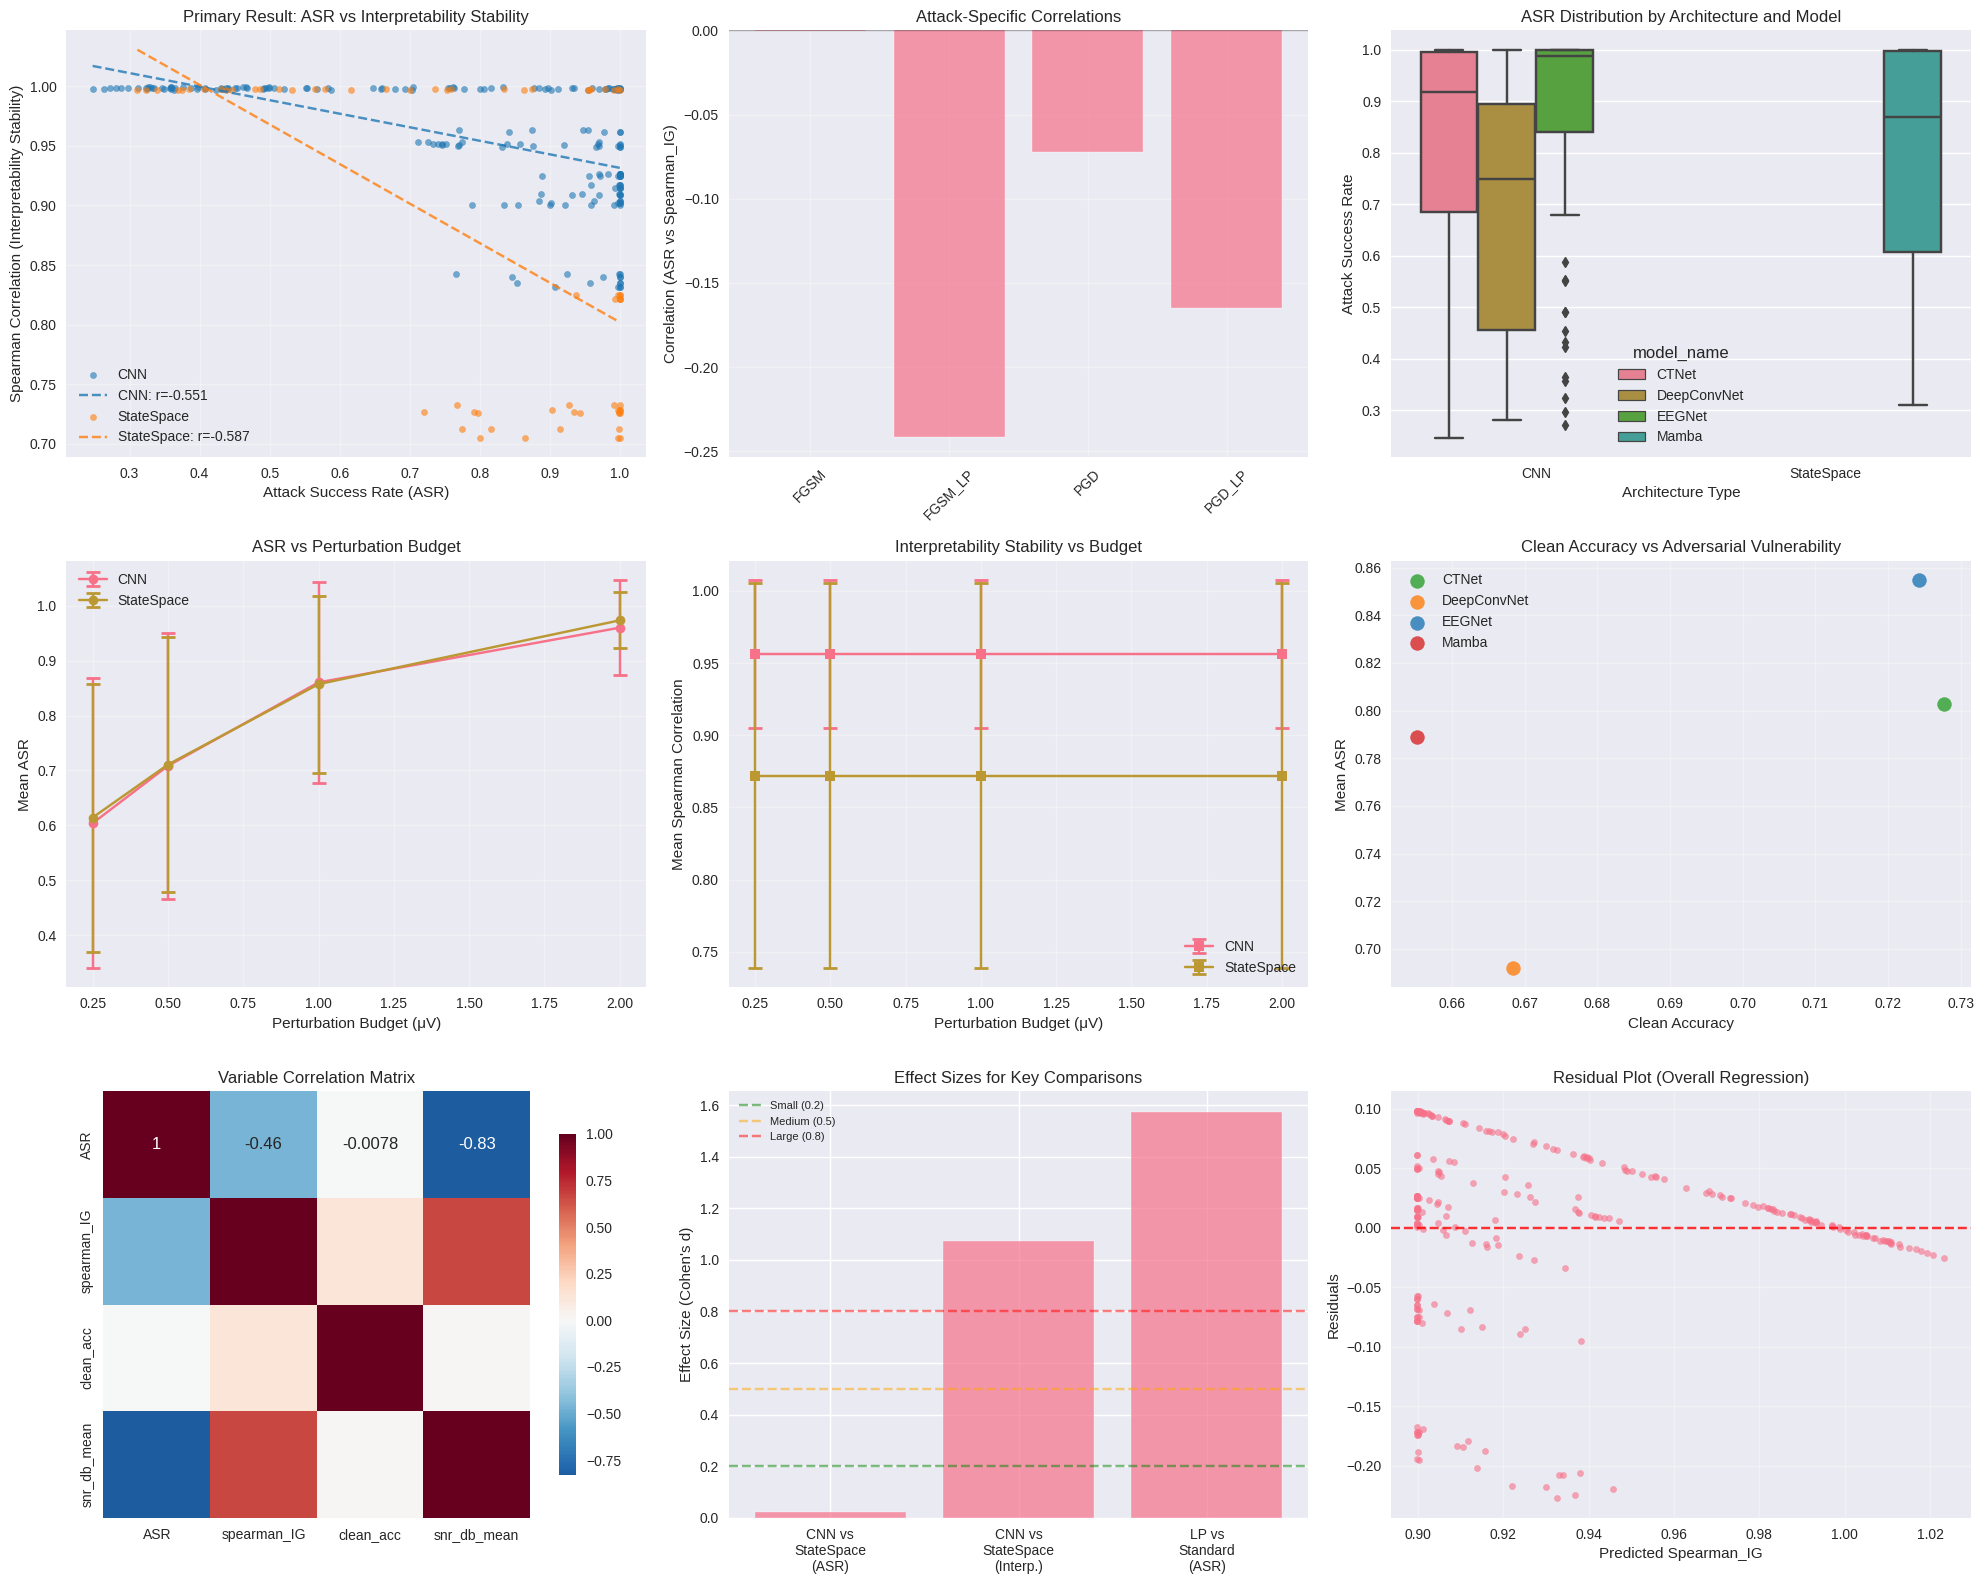

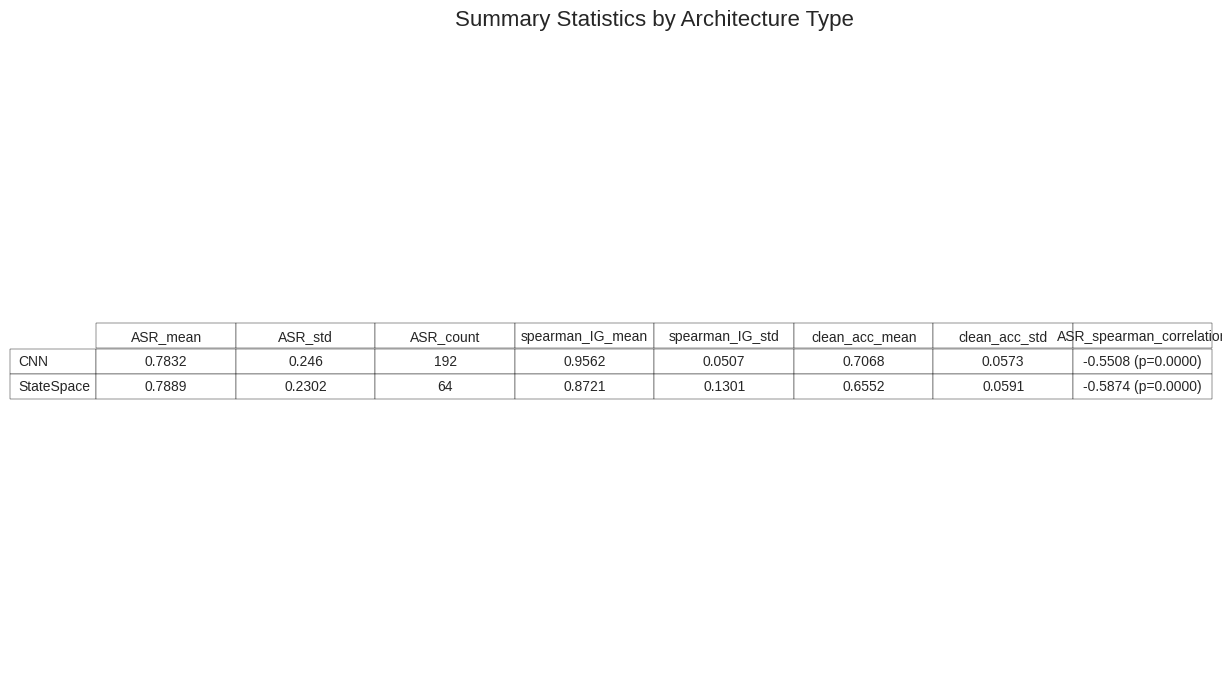

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

def create_visualizations(df_analysis):
    """
    Create comprehensive visualizations for interpretability-robustness study
    """

    # Set style
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))

    # ================================================================
    # 1. Main Result: ASR vs Spearman_IG by Architecture
    # ================================================================
    ax1 = plt.subplot(3, 3, 1)

    # Architecture colors
    colors = {'CNN': '#1f77b4', 'StateSpace': '#ff7f0e'}

    for arch in ['CNN', 'StateSpace']:
        subset = df_analysis[df_analysis['architecture_type'] == arch]

        # Scatter plot
        plt.scatter(subset['ASR'], subset['spearman_IG'],
                   alpha=0.6, s=20, color=colors[arch], label=arch)

        # Regression line
        slope, intercept, r_value, p_value, std_err = stats.linregress(subset['ASR'], subset['spearman_IG'])
        x_line = np.linspace(subset['ASR'].min(), subset['ASR'].max(), 100)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, color=colors[arch], linestyle='--', alpha=0.8,
                label=f'{arch}: r={r_value:.3f}')

    plt.xlabel('Attack Success Rate (ASR)')
    plt.ylabel('Spearman Correlation (Interpretability Stability)')
    plt.title('Primary Result: ASR vs Interpretability Stability')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ================================================================
    # 2. Attack-Type Specific Correlations
    # ================================================================
    ax2 = plt.subplot(3, 3, 2)

    # Calculate correlations by attack type
    attack_corrs = []
    attack_types = []
    attack_pvals = []

    for attack in df_analysis['attack'].unique():
        subset = df_analysis[df_analysis['attack'] == attack]
        if len(subset) > 10:
            corr, pval = pearsonr(subset['ASR'], subset['spearman_IG'])
            attack_corrs.append(corr)
            attack_types.append(attack)
            attack_pvals.append(pval)

    # Bar plot with significance indicators
    bars = plt.bar(range(len(attack_corrs)), attack_corrs, alpha=0.7)
    plt.xticks(range(len(attack_types)), attack_types, rotation=45)
    plt.ylabel('Correlation (ASR vs Spearman_IG)')
    plt.title('Attack-Specific Correlations')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Add significance markers
    for i, (bar, pval) in enumerate(zip(bars, attack_pvals)):
        if pval < 0.001:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, '***',
                    ha='center', va='bottom', fontsize=12)
        elif pval < 0.01:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, '**',
                    ha='center', va='bottom', fontsize=12)
        elif pval < 0.05:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, '*',
                    ha='center', va='bottom', fontsize=12)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # ================================================================
    # 3. ASR Distribution by Architecture and Model
    # ================================================================
    ax3 = plt.subplot(3, 3, 3)

    sns.boxplot(data=df_analysis, x='architecture_type', y='ASR', hue='model_name', ax=ax3)
    plt.title('ASR Distribution by Architecture and Model')
    plt.ylabel('Attack Success Rate')
    plt.xlabel('Architecture Type')

    # ================================================================
    # 4. Perturbation Budget Effects
    # ================================================================
    ax4 = plt.subplot(3, 3, 4)

    # Filter data with budget information
    df_budget = df_analysis.dropna(subset=['muV_budget'])

    # Plot budget effects by architecture
    for arch in ['CNN', 'StateSpace']:
        subset = df_budget[df_budget['architecture_type'] == arch]
        budget_means = subset.groupby('muV_budget')['ASR'].mean()
        budget_stds = subset.groupby('muV_budget')['ASR'].std()

        plt.errorbar(budget_means.index, budget_means.values, yerr=budget_stds.values,
                    marker='o', label=arch, capsize=5, capthick=2)

    plt.xlabel('Perturbation Budget (μV)')
    plt.ylabel('Mean ASR')
    plt.title('ASR vs Perturbation Budget')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ================================================================
    # 5. Interpretability Stability by Budget
    # ================================================================
    ax5 = plt.subplot(3, 3, 5)

    for arch in ['CNN', 'StateSpace']:
        subset = df_budget[df_budget['architecture_type'] == arch]
        budget_means = subset.groupby('muV_budget')['spearman_IG'].mean()
        budget_stds = subset.groupby('muV_budget')['spearman_IG'].std()

        plt.errorbar(budget_means.index, budget_means.values, yerr=budget_stds.values,
                    marker='s', label=arch, capsize=5, capthick=2)

    plt.xlabel('Perturbation Budget (μV)')
    plt.ylabel('Mean Spearman Correlation')
    plt.title('Interpretability Stability vs Budget')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ================================================================
    # 6. Model-Specific Performance
    # ================================================================
    ax6 = plt.subplot(3, 3, 6)

    # Clean accuracy vs ASR by model
    model_summary = df_analysis.groupby('model_name').agg({
        'clean_acc': 'mean',
        'ASR': 'mean',
        'spearman_IG': 'mean'
    }).reset_index()

    colors_model = {'EEGNet': '#1f77b4', 'DeepConvNet': '#ff7f0e',
                   'CTNet': '#2ca02c', 'Mamba': '#d62728'}

    for _, row in model_summary.iterrows():
        plt.scatter(row['clean_acc'], row['ASR'], s=100,
                   color=colors_model[row['model_name']],
                   label=row['model_name'], alpha=0.8)

    plt.xlabel('Clean Accuracy')
    plt.ylabel('Mean ASR')
    plt.title('Clean Accuracy vs Adversarial Vulnerability')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ================================================================
    # 7. Correlation Matrix Heatmap
    # ================================================================
    ax7 = plt.subplot(3, 3, 7)

    # Create correlation matrix for key variables
    corr_vars = ['ASR', 'spearman_IG', 'clean_acc', 'snr_db_mean']
    corr_matrix = df_analysis[corr_vars].corr()

    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                square=True, ax=ax7, cbar_kws={'shrink': 0.8})
    plt.title('Variable Correlation Matrix')

    # ================================================================
    # 8. Effect Size Visualization
    # ================================================================
    ax8 = plt.subplot(3, 3, 8)

    # Cohen's d for different comparisons
    effect_sizes = []
    comparisons = []

    # Architecture comparison
    cnn_asr = df_analysis[df_analysis['architecture_type'] == 'CNN']['ASR']
    ss_asr = df_analysis[df_analysis['architecture_type'] == 'StateSpace']['ASR']
    pooled_std = np.sqrt(((len(cnn_asr)-1)*cnn_asr.var() + (len(ss_asr)-1)*ss_asr.var()) /
                        (len(cnn_asr) + len(ss_asr) - 2))
    cohens_d_arch = (cnn_asr.mean() - ss_asr.mean()) / pooled_std
    effect_sizes.append(abs(cohens_d_arch))
    comparisons.append('CNN vs\nStateSpace\n(ASR)')

    # Interpretability comparison
    cnn_ig = df_analysis[df_analysis['architecture_type'] == 'CNN']['spearman_IG']
    ss_ig = df_analysis[df_analysis['architecture_type'] == 'StateSpace']['spearman_IG']
    pooled_std_ig = np.sqrt(((len(cnn_ig)-1)*cnn_ig.var() + (len(ss_ig)-1)*ss_ig.var()) /
                           (len(cnn_ig) + len(ss_ig) - 2))
    cohens_d_ig = (cnn_ig.mean() - ss_ig.mean()) / pooled_std_ig
    effect_sizes.append(abs(cohens_d_ig))
    comparisons.append('CNN vs\nStateSpace\n(Interp.)')

    # Attack type comparison (LP vs standard)
    lp_attacks = df_analysis[df_analysis['attack'].str.contains('_LP', na=False)]['ASR']
    std_attacks = df_analysis[~df_analysis['attack'].str.contains('_LP', na=False) &
                             df_analysis['attack'].isin(['FGSM', 'PGD'])]['ASR']
    if len(lp_attacks) > 0 and len(std_attacks) > 0:
        pooled_std_att = np.sqrt(((len(lp_attacks)-1)*lp_attacks.var() + (len(std_attacks)-1)*std_attacks.var()) /
                                (len(lp_attacks) + len(std_attacks) - 2))
        cohens_d_att = (lp_attacks.mean() - std_attacks.mean()) / pooled_std_att
        effect_sizes.append(abs(cohens_d_att))
        comparisons.append('LP vs\nStandard\n(ASR)')

    bars = plt.bar(range(len(effect_sizes)), effect_sizes, alpha=0.7)
    plt.xticks(range(len(comparisons)), comparisons)
    plt.ylabel("Effect Size (Cohen's d)")
    plt.title('Effect Sizes for Key Comparisons')

    # Add effect size interpretation lines
    plt.axhline(y=0.2, color='green', linestyle='--', alpha=0.5, label='Small (0.2)')
    plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium (0.5)')
    plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Large (0.8)')
    plt.legend(fontsize=8)

    # ================================================================
    # 9. Residual Analysis
    # ================================================================
    ax9 = plt.subplot(3, 3, 9)

    # Overall regression residuals
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_analysis['ASR'], df_analysis['spearman_IG'])
    predicted = slope * df_analysis['ASR'] + intercept
    residuals = df_analysis['spearman_IG'] - predicted

    plt.scatter(predicted, residuals, alpha=0.6, s=20)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.8)
    plt.xlabel('Predicted Spearman_IG')
    plt.ylabel('Residuals')
    plt.title('Residual Plot (Overall Regression)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ================================================================
    # Additional Statistical Summary Figure
    # ================================================================

    # Create a summary statistics table visualization
    fig2, ax_table = plt.subplots(figsize=(12, 8))
    ax_table.axis('tight')
    ax_table.axis('off')

    # Summary statistics by architecture
    summary_stats = df_analysis.groupby('architecture_type').agg({
        'ASR': ['mean', 'std', 'count'],
        'spearman_IG': ['mean', 'std'],
        'clean_acc': ['mean', 'std']
    }).round(4)

    # Flatten column names
    summary_stats.columns = [f'{col[0]}_{col[1]}' for col in summary_stats.columns]

    # Add correlation values
    arch_correlations = {}
    for arch in ['CNN', 'StateSpace']:
        subset = df_analysis[df_analysis['architecture_type'] == arch]
        corr, pval = pearsonr(subset['ASR'], subset['spearman_IG'])
        arch_correlations[arch] = f"{corr:.4f} (p={pval:.4f})"

    summary_stats['ASR_spearman_correlation'] = [arch_correlations['CNN'],
                                                arch_correlations['StateSpace']]

    # Create table
    table = ax_table.table(cellText=summary_stats.values,
                          rowLabels=summary_stats.index,
                          colLabels=summary_stats.columns,
                          cellLoc='center',
                          loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    plt.title('Summary Statistics by Architecture Type', fontsize=16, pad=20)
    plt.show()

    return fig, fig2

# Usage:
fig1, fig2 = create_visualizations(df_analysis)

# Calculating the explanation Blind Spot

In [ ]:
# Define a threshold for explanation similarity
explanation_threshold = 0.001

df = df_aggregated.copy()
# Create a new binary column: 1 if the explanation was fooled, 0 otherwise
df['explanation_fooled'] = (df['spearman_IG'] < explanation_threshold).astype(int)

In [ ]:
# Filter the dataset to only include successful attacks
successful_attacks_df = df[df['ASR'] == 1]

# Calculate the Explanation ASR
# This is the mean of the 'explanation_fooled' column for successful attacks
explanation_asr = successful_attacks_df['explanation_fooled'].mean()

print(f"Explanation Attack Success Rate (E-ASR): {explanation_asr:.2%}")
print(f"This means {explanation_asr:.2%} of successful attacks also significantly altered the explanation.")

Explanation Attack Success Rate (E-ASR): 0.00%
This means 0.00% of successful attacks also significantly altered the explanation.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your DataFrame is called 'df'
# Plot distribution of spearman_IG
# plt.figure(figsize=(8, 5))
# sns.histplot(df['spearman_IG'], kde=True, bins=30)
# plt.title('Distribution of Spearman IG Values')
# plt.xlabel('Spearman IG')
# plt.ylabel('Frequency')
# plt.show()

# Calculate median spearman_IG for all data and for successful attacks
median_spearman_all = df['spearman_IG'].median()
median_spearman_success = df[df['ASR'] == 1]['spearman_IG'].median()

print(f"Median spearman_IG for all samples: {median_spearman_all:.4f}")
print(f"Median spearman_IG for successful attacks: {median_spearman_success:.4f}")

Median spearman_IG for all samples: 0.9800
Median spearman_IG for successful attacks: 0.9144


In [ ]:
# Set threshold based on your data - here, using median of successful attacks
explanation_threshold = median_spearman_success  # or use a fixed value like 0.3 if preferred

# Create a binary column for explanation fooled
df['explanation_fooled'] = (df['spearman_IG'] < explanation_threshold).astype(int)

# Calculate overall Explanation Attack Success Rate (E-ASR)
successful_attacks_df = df[df['ASR'] == 1]
explanation_asr = successful_attacks_df['explanation_fooled'].mean()
print(f"\nExplanation Attack Success Rate (E-ASR) at threshold {explanation_threshold:.4f}: {explanation_asr:.2%}")


Explanation Attack Success Rate (E-ASR) at threshold 0.9144: 48.08%


In [ ]:
# Group by architecture
e_asr_by_architecture = successful_attacks_df.groupby('architecture_type')['explanation_fooled'].mean()
print("\nE-ASR by Architecture:")
print(e_asr_by_architecture)

# Group by attack type
e_asr_by_attack = successful_attacks_df.groupby('attack')['explanation_fooled'].mean()
print("\nE-ASR by Attack Type:")
print(e_asr_by_attack)

# Group by both architecture and attack
e_asr_by_arch_attack = successful_attacks_df.groupby(['architecture_type', 'attack'])['explanation_fooled'].mean().reset_index()
print("\nE-ASR by Architecture and Attack:")
print(e_asr_by_arch_attack)


E-ASR by Architecture:
architecture_type
CNN           0.365854
StateSpace    0.909091
Name: explanation_fooled, dtype: float64

E-ASR by Attack Type:
attack
FGSM       0.600000
FGSM_LP    0.000000
PGD        0.516129
PGD_LP     0.000000
Name: explanation_fooled, dtype: float64

E-ASR by Architecture and Attack:
  architecture_type   attack  explanation_fooled
0               CNN     FGSM               0.500
1               CNN  FGSM_LP               0.000
2               CNN      PGD               0.375
3               CNN   PGD_LP               0.000
4        StateSpace     FGSM               1.000
5        StateSpace  FGSM_LP               0.000
6        StateSpace      PGD               1.000


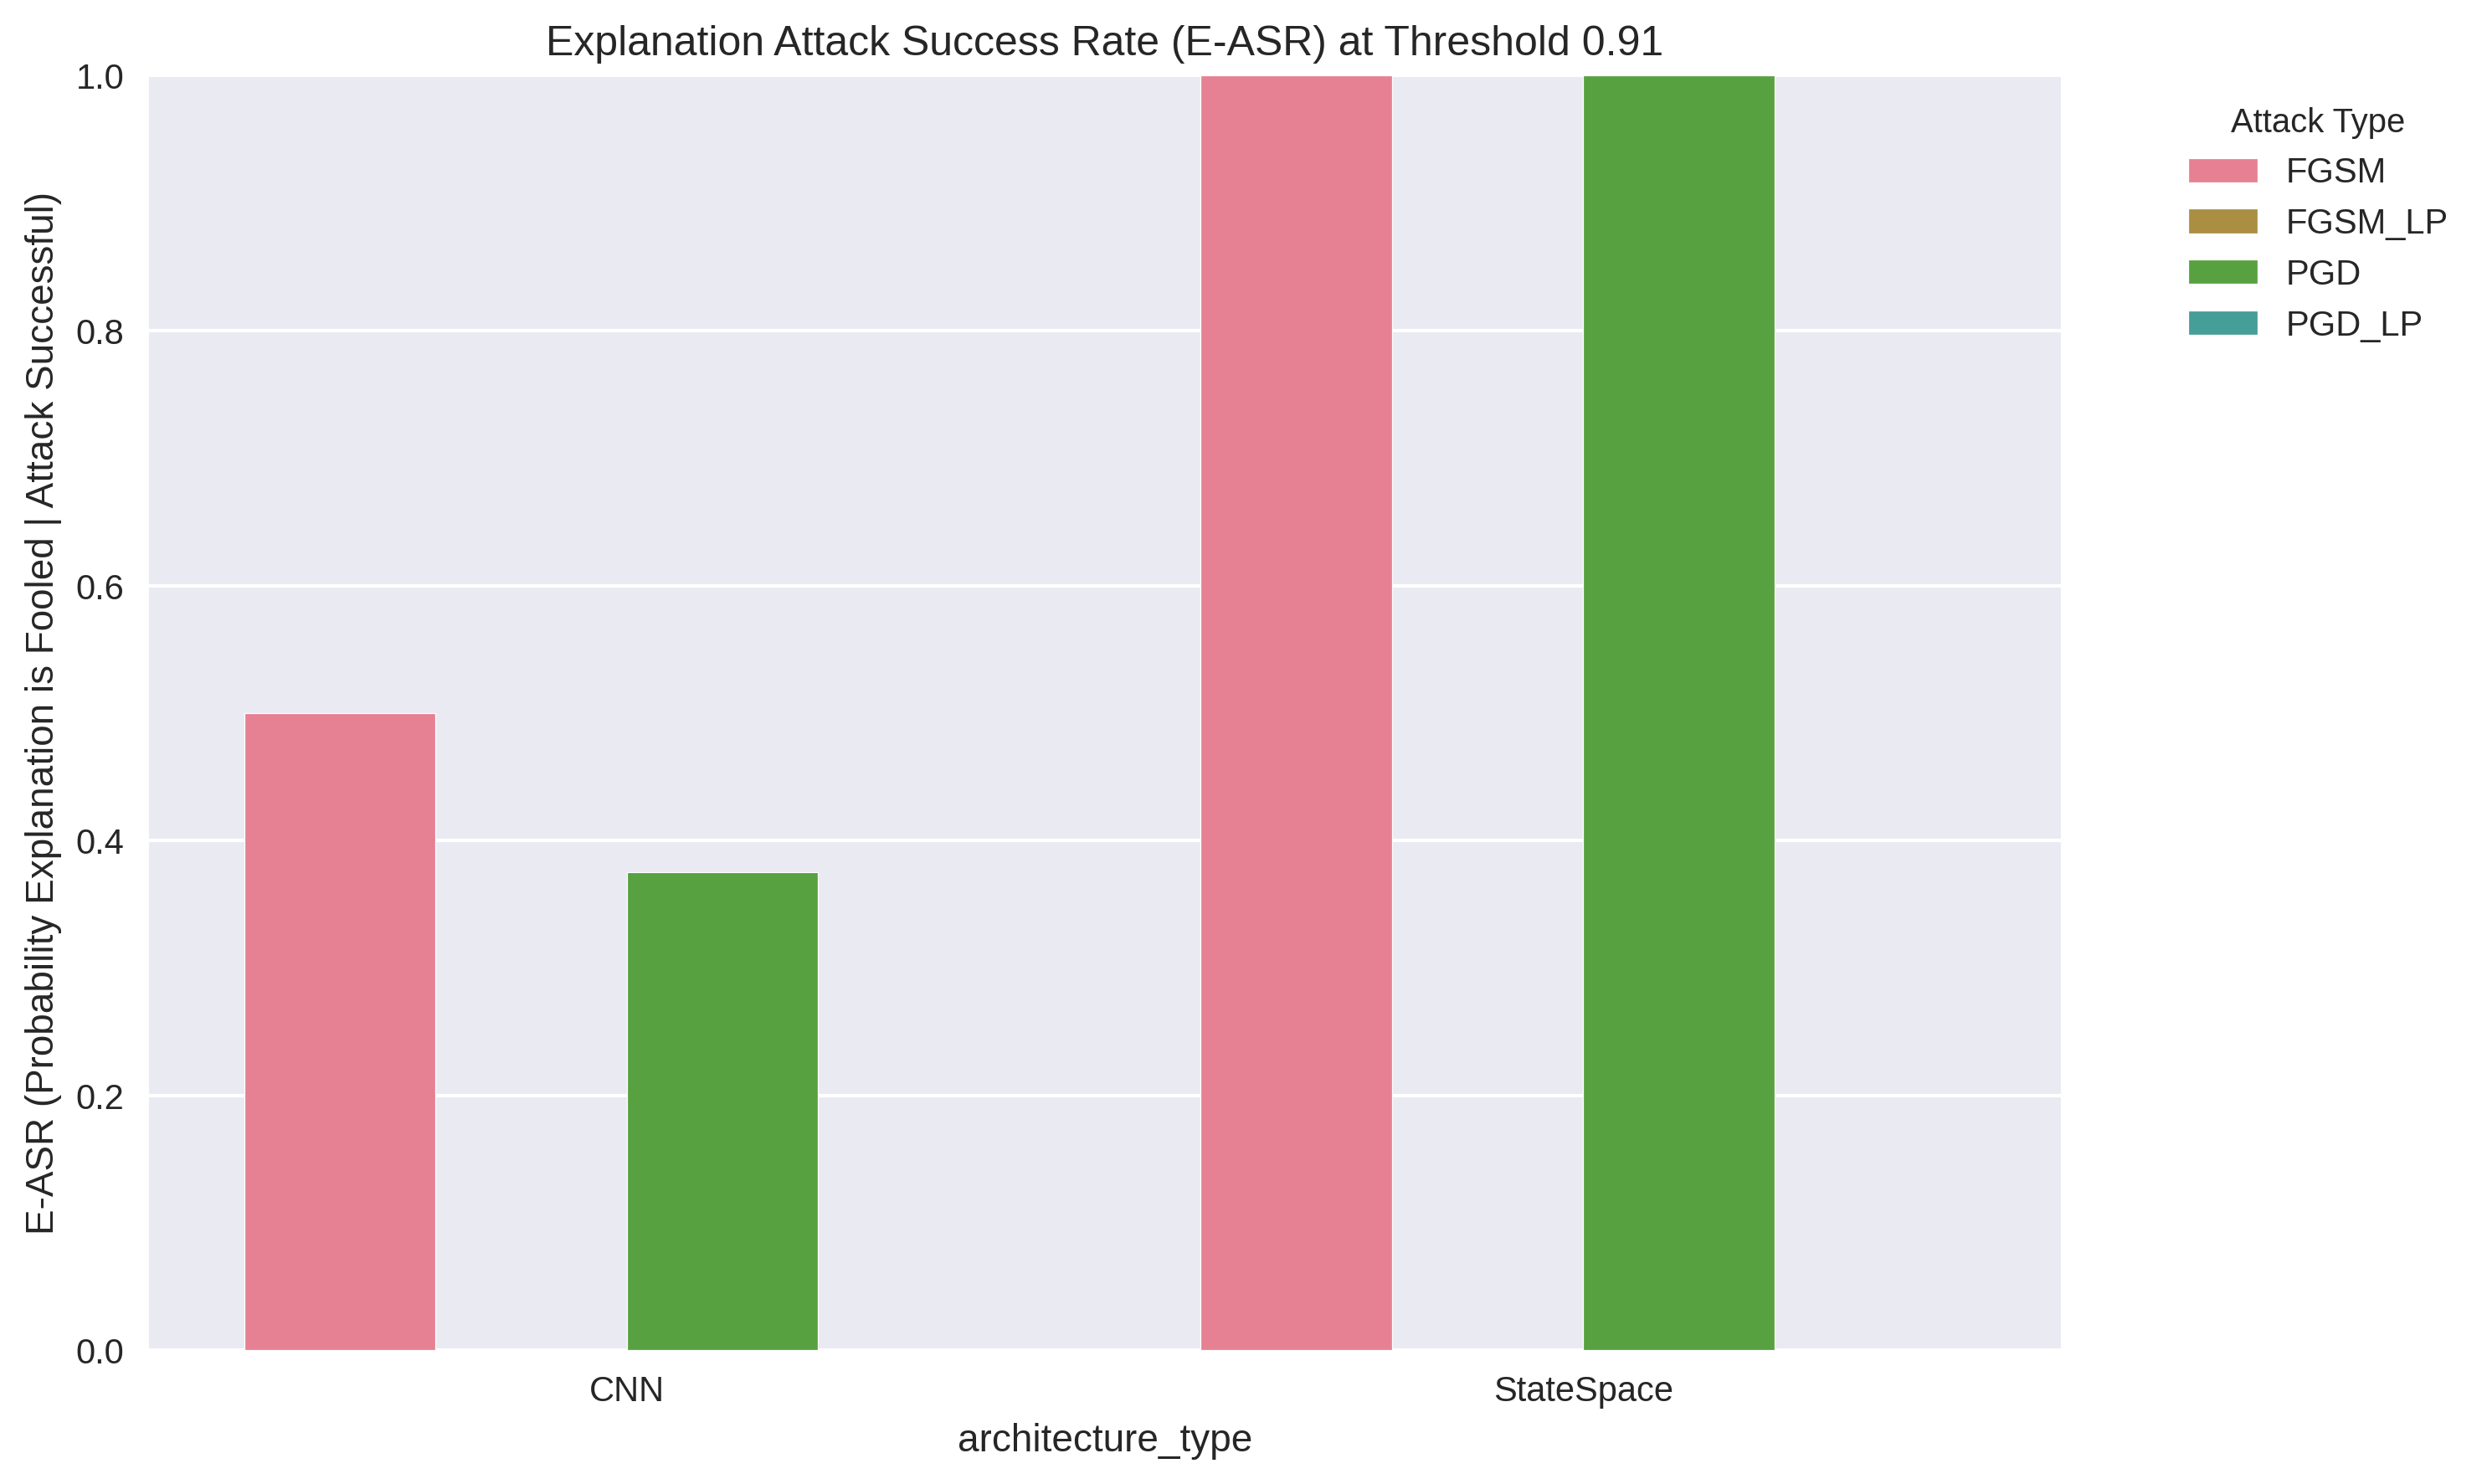

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=e_asr_by_arch_attack, x='architecture_type', y='explanation_fooled', hue='attack')
plt.title(f'Explanation Attack Success Rate (E-ASR) at Threshold {explanation_threshold:.2f}')
plt.ylabel('E-ASR (Probability Explanation is Fooled | Attack Successful)')
plt.ylim(0, 1)
plt.legend(title='Attack Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Misc
## Gathering the IG for explanation shift

Ended up not doing this. Could polish this for another time

In [19]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from captum.attr import IntegratedGradients

# ================== CONFIGURATION ==================
CONFIG = {
    # Model and Data Parameters
    'model_name': 'EEGNet',  # You will manually change this for each run
    'subject_ids': [3, 9],   # Best performing subjects
    'seeds': [42, 31415],    # Best seeds

    # Attack Parameters
    'eps_uV_list': [0.5, 1.0, 2.0],  # Budgets in μV
    'attacks': [
        {'name': 'FGSM'},
        {'name': 'PGD', 'alpha': 0.005, 'iters': 10},
    ],

    # Technical Parameters
    'batch_size': 64,
    'ig_steps': 50,
    'base_out_dir': 'analysis_data_dumps',  # Base directory
}

# ===================================================

# Set device and seeds for reproducibility
device = 'cuda' if torch.cuda.is_available() else 'cpu'
set_all_seeds(CONFIG['seed'])

# ---------- model helpers ----------
def build_model(name, n_chans, n_classes):
    name = name.lower()
    if name == 'eegnet':

        return EEGNetv4(n_chans, n_classes, input_window_samples=None, final_conv_length='auto')
    elif name == 'deepconvnet':

        return Deep4Net(in_chans=n_chans, n_classes=n_classes, input_window_samples=None, final_conv_length='auto')

    elif name == 'ctnet':

        return CTNet(in_chans=n_chans, n_classes=n_classes, input_window_samples=None, final_conv_length='auto')
    elif name in {"mamba", "eegmamba"}:
        return EEGMamba()

    else:
        raise ValueError(f"Unknown model name: {name}")

def load_model(ckpt_path, model_name, n_chans, n_classes):
    path = torch.load(ckpt_path, map_location='cpu')
    model = build_model(model_name, n_chans, n_classes)
    model.load_state_dict(path['state_dict'])
    model.eval().to(device)
    return model



def fgsm_z(model, xz, y, eps_z, zmin, zmax):
    # Your implementation
    xz = xz.clone().detach().requires_grad_(True)
    loss = nn.CrossEntropyLoss()(model(xz), y)
    loss.backward()
    with torch.no_grad():
        adv = xz + eps_z * xz.grad.sign()
        adv = torch.max(torch.min(adv, zmax), zmin)
    return adv.detach()

def pgd_z(model, xz, y, eps_z, alpha, iters, zmin, zmax):
    # Your implementation
    x0 = xz.clone().detach()
    adv = x0 + torch.empty_like(x0).uniform_(-eps_z, eps_z)
    adv = torch.max(torch.min(adv, zmax), zmin)
    for i in range(iters):
        adv.requires_grad_(True)
        loss = nn.CrossEntropyLoss()(model(adv), y)
        loss.backward()
        with torch.no_grad():
            adv = adv + alpha * adv.grad.sign()
            adv = torch.max(torch.min(adv, x0 + eps_z), x0 - eps_z)
            adv = torch.max(torch.min(adv, zmax), zmin)
        adv.grad.zero_()
    return adv.detach()
# ------------------------------------------------

# ---------- 2. NEW HELPER FUNCTIONS ----------
@torch.no_grad()
def predict_with_logits(model, dataloader):
    """Runs model inference and returns predictions, logits, and probabilities."""
    all_preds, all_logits, all_probs = [], [], []
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = model(x_batch)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
    # Return as tensors
    return torch.cat(all_preds, dim=0), torch.cat(all_logits, dim=0), torch.cat(all_probs, dim=0)

def compute_ig(model, input_tensor, target_tensor, steps, internal_bs):
    """Computes Integrated Gradients for a given input and target."""
    ig = IntegratedGradients(model)
    attributions = ig.attribute(inputs=input_tensor,
                               baselines=torch.zeros_like(input_tensor),
                               target=target_tensor,
                               n_steps=steps,
                               internal_batch_size=internal_bs)
    return attributions.detach().cpu()
# ------------------------------------------------

# ---------- 3. MAIN EXECUTION LOGIC ----------
def main():
    print(f"Using device: {device}")
    os.makedirs(CONFIG['out_dir'], exist_ok=True)

    # A. Load Data and Setup
    print("Loading data...")

    Xz, y, train_min_t, train_max_t, train_std_np, train_mean_np, CH_NAMES = load_adv_test_data(CONFIG['subject_id'])
    Xz, y = Xz.to(device), y.to(device)
    n_classes = len(torch.unique(y))
    N, C, T = Xz.shape

    # Calculate z-space bounds
    mean_pre_t = torch.tensor(train_mean_np, device=device, dtype=torch.float32).view(1, C, 1)
    std_pre_t = torch.tensor(train_std_np, device=device, dtype=torch.float32).view(1, C, 1)
    z_min = (train_min_t - mean_pre_t) / std_pre_t
    z_max = (train_max_t - mean_pre_t) / std_pre_t

    # B. Load Model
    print("Loading model...")
    model = load_model(CONFIG['ckpt_path'], CONFIG['load_mode'], CONFIG['model_name'], C, n_classes)
    print(f"Loaded {model.__class__.__name__}")

    # C. Process Clean Data
    print("\n--- Processing CLEAN Data ---")
    clean_loader = DataLoader(TensorDataset(Xz, y), batch_size=CONFIG['batch_size'], shuffle=False)

    clean_preds, clean_logits, clean_probs = predict_with_logits(model, clean_loader)
    print("Computing Clean IG...")
    clean_ig = compute_ig(model, Xz, y, CONFIG['ig_steps'], CONFIG['batch_size'])

    # Initialize results structure
    results = {
        'config': CONFIG,
        model.__class__.__name__: {
            'clean': {
                'x': Xz.cpu(),
                'y': y.cpu(),
                'preds': clean_preds,
                'logits': clean_logits,
                'probs': clean_probs,
                'ig': clean_ig,
            },
            'attacks': {}
        }
    }

    # D. Process Each Attack
    clean_loader = DataLoader(TensorDataset(Xz, y), batch_size=CONFIG['batch_size'], shuffle=False) # Reload for attack loop

    for attack_config in CONFIG['attacks']:
        attack_name = attack_config['name'].upper()
        eps_z = attack_config['eps_z']
        print(f"\n--- Generating {attack_name} Adversarial Examples ---")

        # Generate Adv. Examples
        x_adv_list = []
        for x_batch, y_batch in tqdm(clean_loader, desc=attack_name):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            if attack_name == 'FGSM':
                x_adv_batch = fgsm_z(model, x_batch, y_batch, eps_z, z_min, z_max)
            elif attack_name == 'PGD':
                alpha = attack_config['alpha']
                iters = attack_config['iters']
                x_adv_batch = pgd_z(model, x_batch, y_batch, eps_z, alpha, iters, z_min, z_max)
            else:
                raise ValueError(f"Unknown attack: {attack_name}")
            x_adv_list.append(x_adv_batch.cpu())

        x_adv = torch.cat(x_adv_list, dim=0).to(device)

        # Get predictions and compute IG on adversarial examples
        adv_loader = DataLoader(TensorDataset(x_adv, y), batch_size=CONFIG['batch_size'], shuffle=False)
        adv_preds, adv_logits, adv_probs = predict_with_logits(model, adv_loader)

        print(f"Computing {attack_name} Adversarial IG...")
        adv_ig = compute_ig(model, x_adv, y, CONFIG['ig_steps'], CONFIG['batch_size']) # Using y (true label) for attribution is standard

        # Store results for this attack
        results[model.__class__.__name__]['attacks'][attack_name] = {
            'x_adv': x_adv.cpu(),
            'preds': adv_preds,
            'logits': adv_logits,
            'probs': adv_probs,
            'ig': adv_ig,
            'config': attack_config
        }

    # E. Save Everything
    output_filename = f"S{CONFIG['subject_id']}_{model.__class__.__name__}_{CONFIG['seed']}_FULL_RESULTS.pt"
    output_path = os.path.join(CONFIG['out_dir'], output_filename)
    torch.save(results, output_path)
    print(f"\nComplete dataset saved to:\n{output_path}")

    # F. Print a summary of what was saved for verification
    model_key = model.__class__.__name__
    print("\n--- SAVED DATA SUMMARY ---")
    print(f"Clean Data:")
    print(f"  - X: {results[model_key]['clean']['x'].shape}")
    print(f"  - Y: {results[model_key]['clean']['y'].shape}")
    print(f"  - Predictions: {results[model_key]['clean']['preds'].shape}")
    print(f"  - Logits: {results[model_key]['clean']['logits'].shape}")
    print(f"  - Probabilities: {results[model_key]['clean']['probs'].shape}")
    print(f"  - IG: {results[model_key]['clean']['ig'].shape}")

    for attack_name in results[model_key]['attacks']:
        print(f"\nAttack: {attack_name}")
        attack_data = results[model_key]['attacks'][attack_name]
        print(f"  - X_adv: {attack_data['x_adv'].shape}")
        print(f"  - Predictions: {attack_data['preds'].shape}")
        print(f"  - Logits: {attack_data['logits'].shape}")
        print(f"  - Probabilities: {attack_data['probs'].shape}")
        print(f"  - IG: {attack_data['ig'].shape}")

if __name__ == '__main__':
    main()

Using device: cuda
Loading data...
Loading model...


AttributeError: 'dict' object has no attribute 'eval'